# 1. About Dataset
This dataset provides data from 1st January 2020 to 30th April 2026 in the city of Varanasi, India.

The 4 parameters here are:

- meantemp
- humidity
- wind_speed
- meanpressure

# 2. Importing Dependencies

In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

# 3. Read Dataset


In [4]:
df = pd.read_csv("/kaggle/input/datasets/yshubhamy/vnstdf/vnsdftrain.csv")

df.head()

,YEAR,MO,DY,meantemp,humidity,wind_speed,meanpressure
0,2020,1,1,9.98,82.94,2.09,101.25
1,2020,1,2,13.44,84.70,2.25,101.19
2,2020,1,3,14.00,92.51,2.01,100.86
3,2020,1,4,14.31,85.76,1.95,100.77
4,2020,1,5,13.15,83.57,3.29,100.86


### Transforming date into a single column

In [5]:
# Step 1: Rename columns
df.rename(columns={
    'YEAR': 'year',
    'MO': 'month',
    'DY': 'day'
}, inplace=True)

# Step 2: Create date column
df['date'] = pd.to_datetime(df[['year','month','day']])

# Step 3: Drop unnecessary columns
df = df.drop(columns=['year','month','day'])

# Step 4: Reorder
df = df[['date','meantemp','humidity','wind_speed','meanpressure']]

# Step 5: Sort
df = df.sort_values('date').reset_index(drop=True)

In [6]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2020-01-01,9.98,82.94,2.09,101.25
1,2020-01-02,13.44,84.70,2.25,101.19
2,2020-01-03,14.00,92.51,2.01,100.86
3,2020-01-04,14.31,85.76,1.95,100.77
4,2020-01-05,13.15,83.57,3.29,100.86


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2193 non-null   datetime64[ns]
 1   meantemp      2193 non-null   float64       
 2   humidity      2193 non-null   float64       
 3   wind_speed    2193 non-null   float64       
 4   meanpressure  2193 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 85.8 KB


In [8]:
df["date"] = pd.to_datetime(df["date"])

df.set_index("date", inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2193 entries, 2020-01-01 to 2026-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      2193 non-null   float64
 1   humidity      2193 non-null   float64
 2   wind_speed    2193 non-null   float64
 3   meanpressure  2193 non-null   float64
dtypes: float64(4)
memory usage: 85.7 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
meantemp,2193.0,26.105486,6.964722,9.21,20.51,27.90,30.82,41.63
humidity,2193.0,57.462417,24.026007,6.92,35.38,61.15,80.13,94.29
wind_speed,2193.0,2.969129,1.187767,0.76,2.12,2.78,3.60,9.93
meanpressure,2193.0,99.875960,0.666866,98.40,99.31,99.82,100.48,101.40


# 4. Missing Values Checks

In [10]:
df.isnull().sum()

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [11]:
df.columns = df.columns.str.strip()

# 5. Exploratory Data Analysis and Visualization

## 5.1 Time Series Plot

In [12]:
pip install ipython nbformat

Note: you may need to restart the kernel to use updated packages.


In [13]:
meantemp_ts = px.line(df, x=df.index, y="meantemp",
        title="Mean Temperature Over Time")

humidity_ts = px.line(df, x=df.index, y="humidity",
        title="Humidity Over Time")

wind_speed_ts = px.line(df, x=df.index, y="wind_speed",
        title="Wind Speed Over Time")

meanpressure_ts = px.line(df, x=df.index, y="meanpressure",
        title="Meanpressure Over Time")

meantemp_ts.show()
humidity_ts.show()
wind_speed_ts.show()
meanpressure_ts.show()


## 5.2 Rolling Mean & Trend

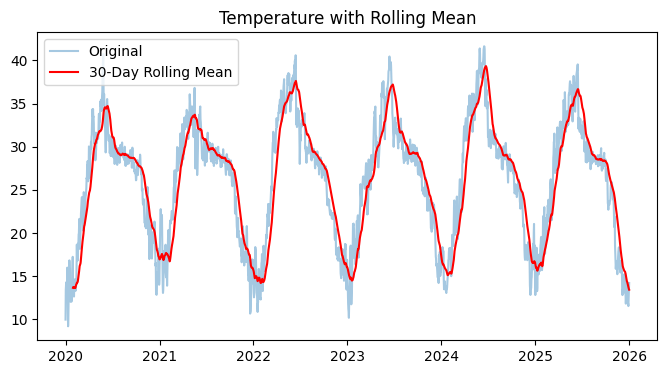

In [14]:
df["rolling_30"] = df["meantemp"].rolling(30).mean()

plt.figure(figsize=(8, 4))
plt.plot(df.index, df["meantemp"], alpha=0.4, label="Original")
plt.plot(df.index, df["rolling_30"], color="red", label="30-Day Rolling Mean")
plt.title("Temperature with Rolling Mean")
plt.legend()
plt.show()

## 5.3 Seasonal Decomposition

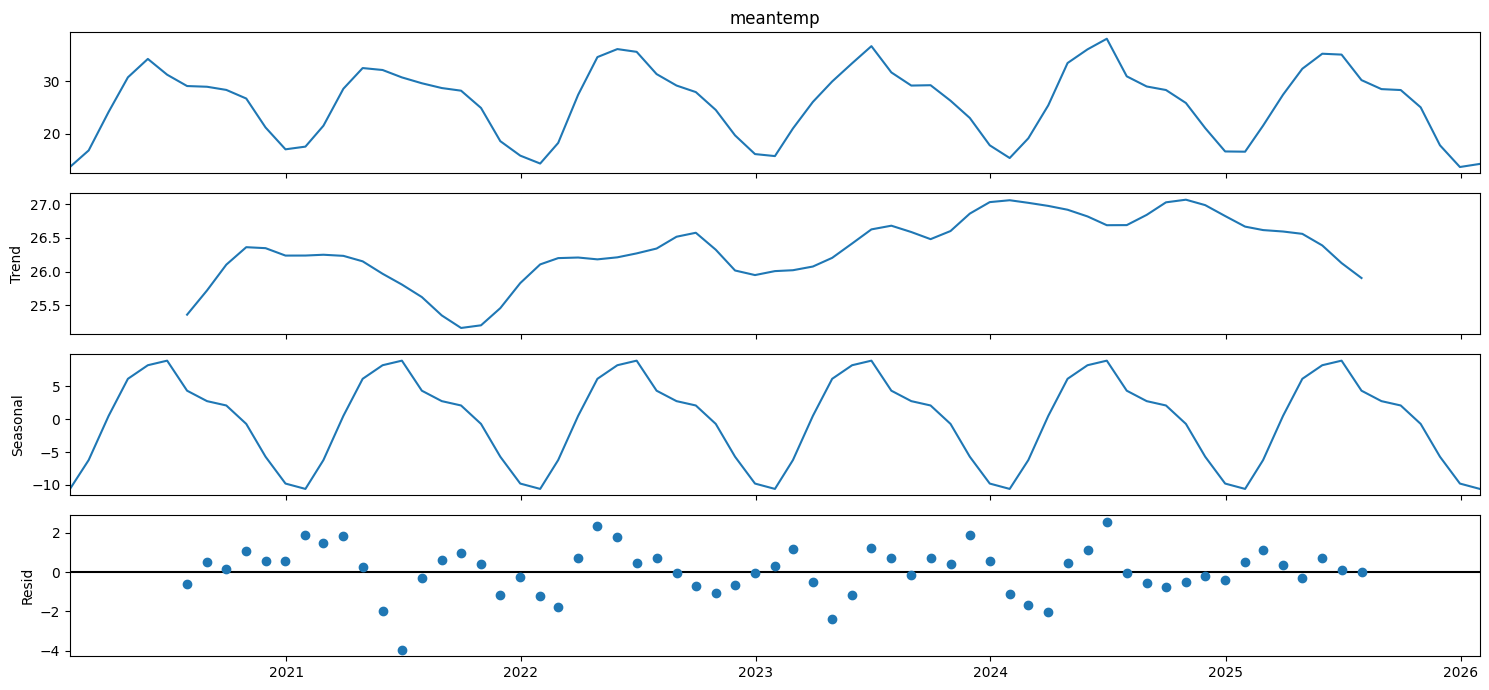

In [15]:
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = [15, 7]

# Select the 'meantemp' column and resample it to monthly frequency
data_monthly = df['meantemp'].resample('M').mean()

# Perform seasonal decomposition for 'meantemp' feature
decomposition = sm.tsa.seasonal_decompose(data_monthly, period=12)

# Plot the decomposition
fig = decomposition.plot()
plt.show()

## 5.4 Temperature over the years by month

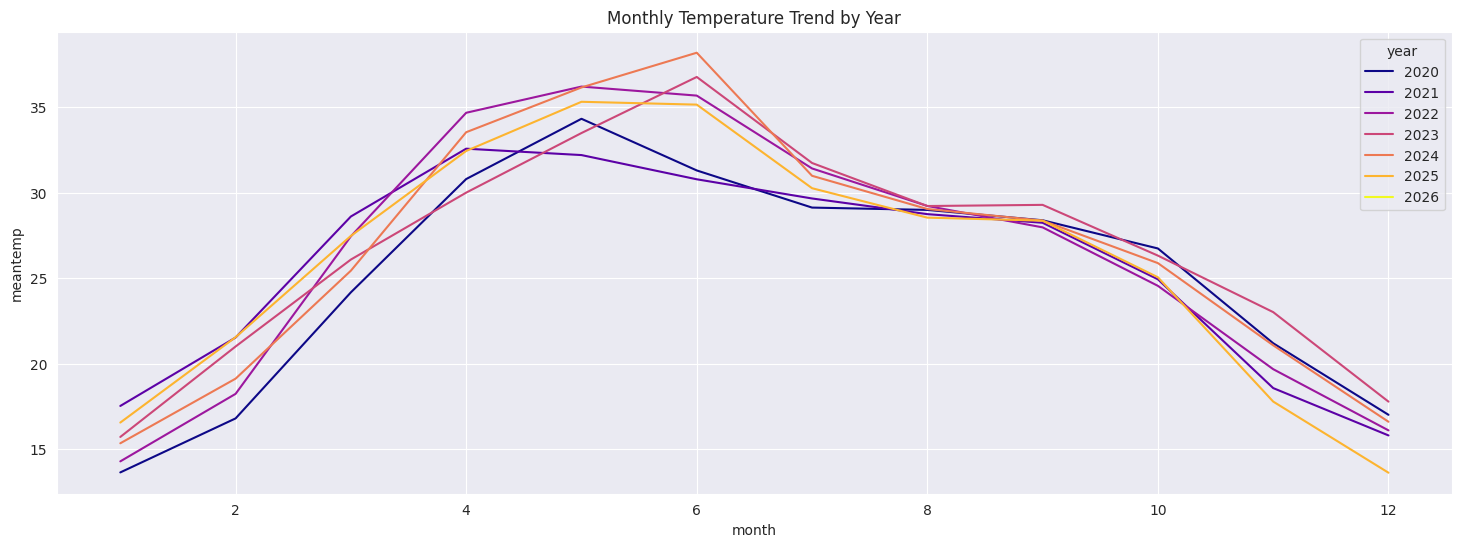

In [16]:
df_eda = df.copy()
df_eda["year"] = df_eda.index.year
df_eda["month"] = df_eda.index.month

plt.figure(figsize=(18, 6))
sns.set_style('darkgrid')
sns.lineplot(
    data=df_eda,
    x="month",
    y="meantemp",
    hue="year",
    palette='plasma',
    ci=None
)

plt.title("Monthly Temperature Trend by Year")
plt.show()

## 5.5 Plotting Features over time (Month)

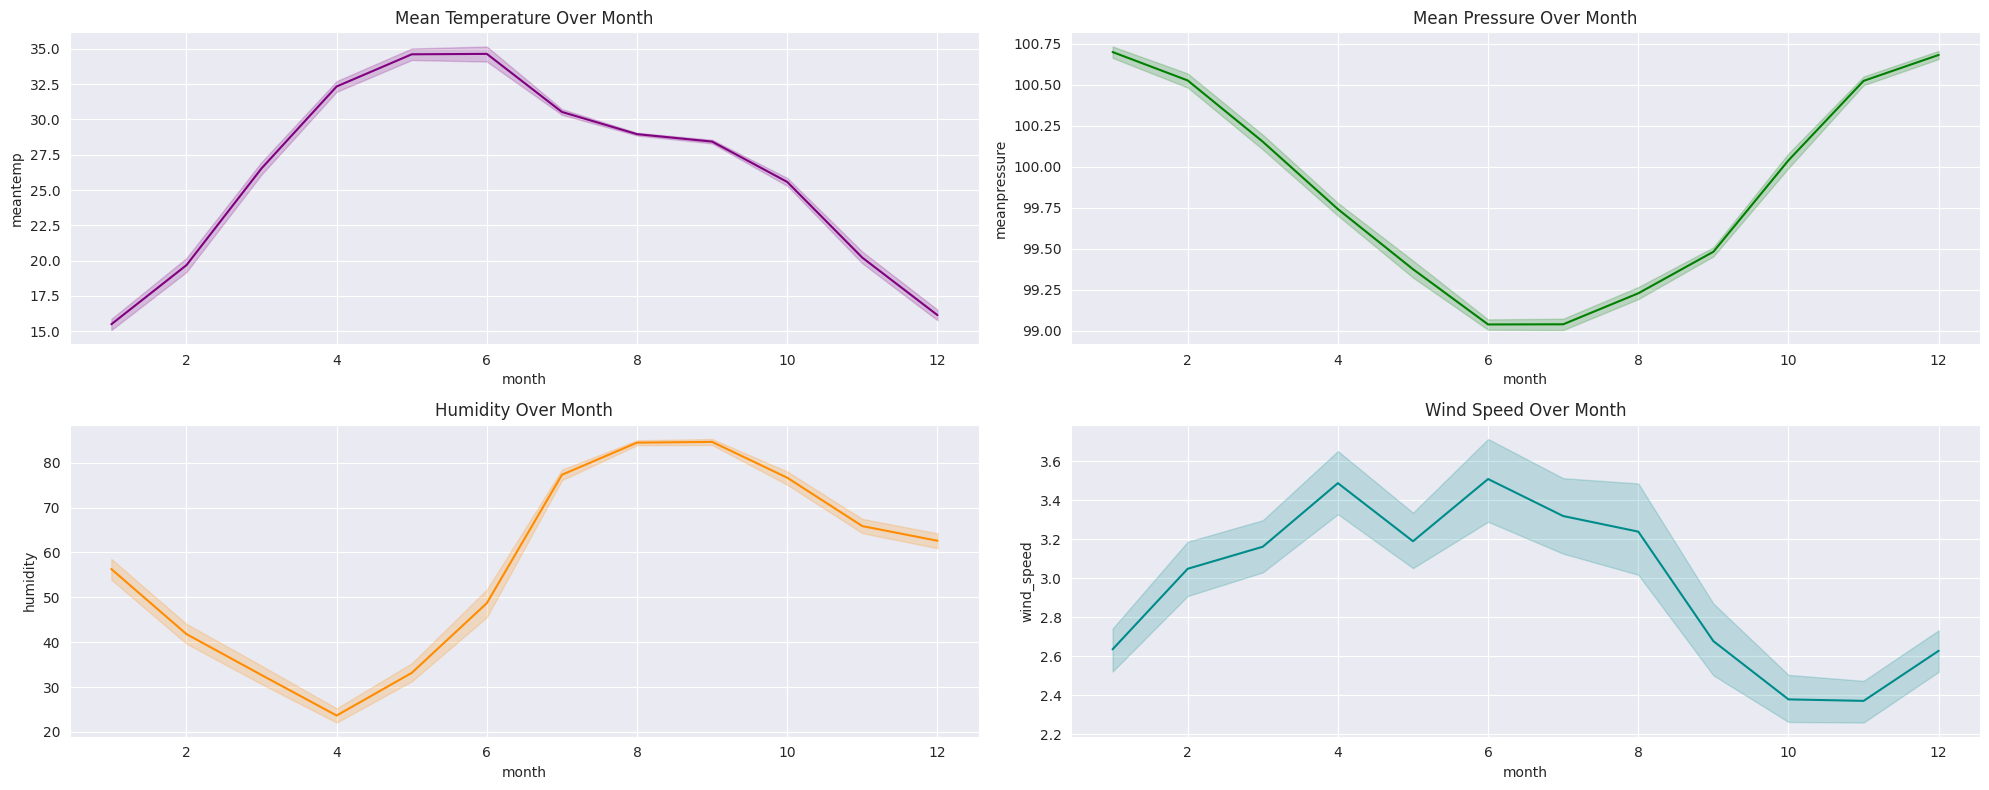

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 8))

sns.set_style('darkgrid')

# Plot each parameter against the 'month'
sns.lineplot(x='month', y='meantemp', data=df_eda, color='purple', ax=axes[0][0])
axes[0][0].set_title('Mean Temperature Over Month')

sns.lineplot(x='month', y='humidity', data=df_eda, color='darkorange', ax=axes[1][0])
axes[1][0].set_title('Humidity Over Month')

sns.lineplot(x='month', y='meanpressure', data=df_eda, color='green', ax=axes[0][1])
axes[0][1].set_title('Mean Pressure Over Month')

sns.lineplot(x='month', y='wind_speed', data=df_eda, color='darkcyan', ax=axes[1][1])
axes[1][1].set_title('Wind Speed Over Month')

plt.tight_layout()
plt.show()

## 5.6 Heatmap

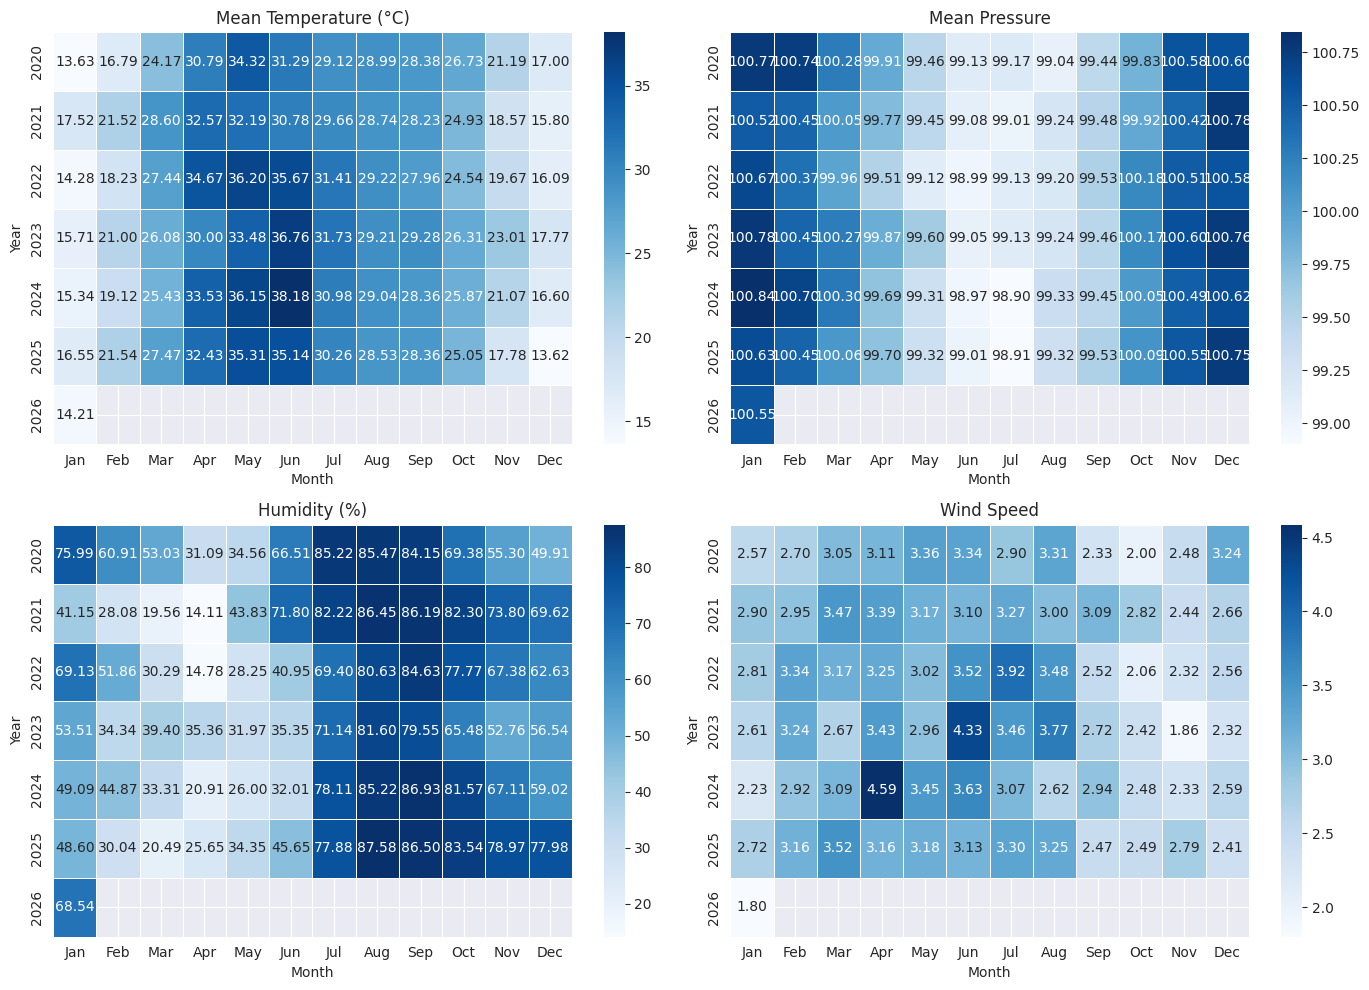

In [18]:
features = ['meantemp', 'meanpressure', 'humidity', 'wind_speed']
titles = [
    'Mean Temperature (°C)',
    'Mean Pressure',
    'Humidity (%)',
    'Wind Speed'
]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    pivot = df_eda.pivot_table(
        values=feature,
        index='year',
        columns='month'
    )
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

    sns.heatmap(
        pivot,
        ax=axes[i],
        cmap='Blues',
        annot=True,
        fmt='.2f',
        linewidths=0.5,
    )

    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Year')

plt.tight_layout()
plt.show()

## 5.7 Histograms

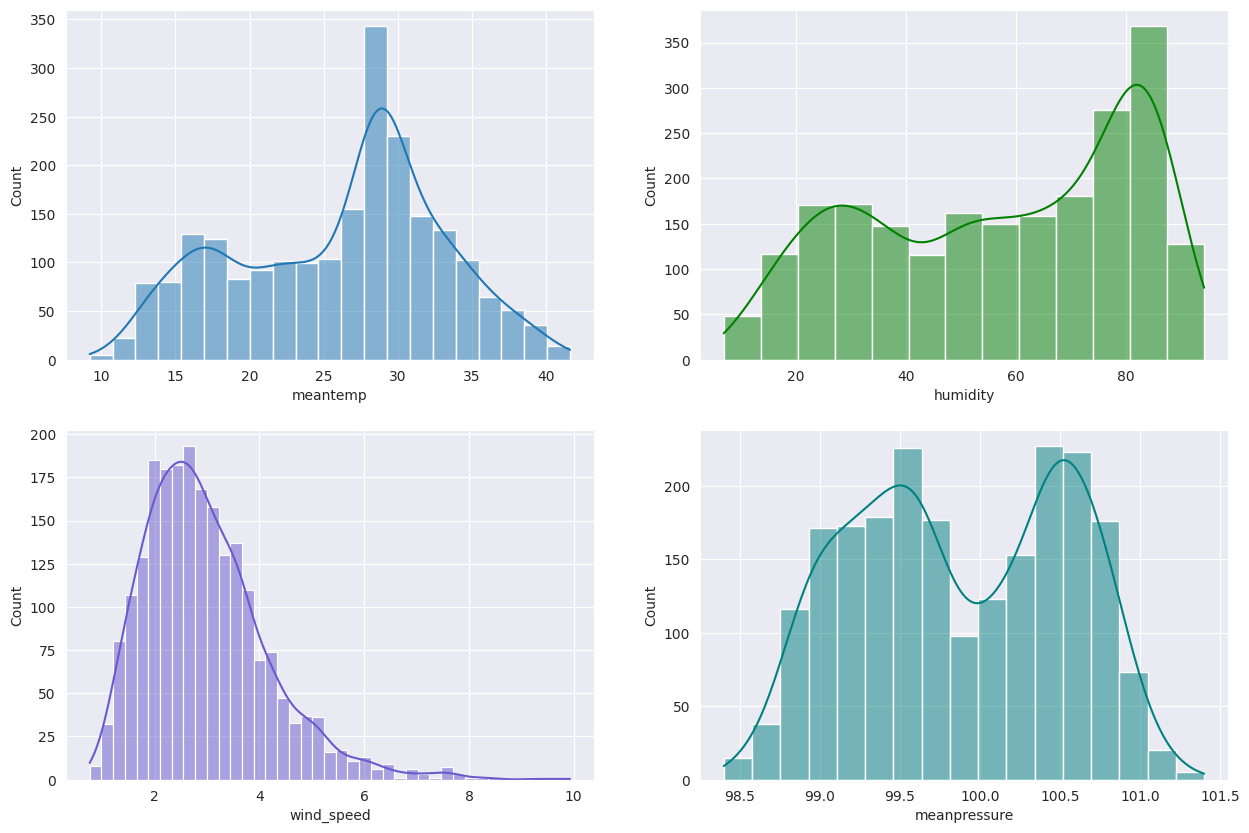

In [19]:
# Reset seaborn style to default
sns.set_style('darkgrid')

# Create subplots
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Plot histograms with KDE
sns.histplot(data=df_eda, x="meantemp", ax=ax[0][0], kde=True)

sns.histplot(data=df_eda, x="humidity", ax=ax[0][1], kde=True, color='green')

sns.histplot(data=df_eda, x="wind_speed", ax=ax[1][0], kde=True, color='slateblue')

sns.histplot(data=df_eda, x="meanpressure", ax=ax[1][1], kde=True, color='teal')

# Show the plot
plt.show()

# 6. Feature Selection

- After all these visualisations we can say that average pressure (meanpressure) is almost the same in every month and has almost no correlation with meantemp feature.

I decided to continue with the 3 features for modelling: meantemp(target), humidity, wind_speed.

In [20]:
df = df_eda[['meantemp', 'humidity', 'wind_speed']]
df.head()

,meantemp,humidity,wind_speed
date,,,
2020-01-01,9.98,82.94,2.09
2020-01-02,13.44,84.70,2.25
2020-01-03,14.00,92.51,2.01
2020-01-04,14.31,85.76,1.95
2020-01-05,13.15,83.57,3.29


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2193 entries, 2020-01-01 to 2026-01-01
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   meantemp    2193 non-null   float64
 1   humidity    2193 non-null   float64
 2   wind_speed  2193 non-null   float64
dtypes: float64(3)
memory usage: 68.5 KB


In [22]:
# Creating a new Dataframe for ARIMA-SARIMA Models
df1 = df.copy()
df1

,meantemp,humidity,wind_speed
date,,,
2020-01-01,9.98,82.94,2.09
2020-01-02,13.44,84.70,2.25
2020-01-03,14.00,92.51,2.01
2020-01-04,14.31,85.76,1.95
2020-01-05,13.15,83.57,3.29
...,...,...,...
2025-12-28,11.85,79.74,2.28
2025-12-29,11.55,79.65,2.33
2025-12-30,12.60,71.29,2.66


# 7. ARIMA-SARIMA Models

**ARIMA** : Non-seasonal Autoregressive Integrated Moving Averages

**SARIMA** : Seasonal ARIMA

**SARIMAX** : Seasonal ARIMA with exogenous variables

If a time series, has seasonal patterns, then we need to add seasonal terms and it becomes SARIMA, short for Seasonal ARIMA.

## Steps for building ARIMA-SARIMA models:


#### 1. Check Stationarity:
- Verify the stationarity of each series using ADF (Augmented Dickey-Fuller)
- Display with ACF and PACF plots.

#### 2. Make Series Stationary:
Apply transformations to make the target and exogenous variables stationary if needed. Common methods include differencing and log transformations.

#### 3. Model the Relationship:
Use the stationary series in your ARIMA or SARIMA model.

For ARIMA (AutoRegressive Integrated Moving Average) and SARIMA (Seasonal AutoRegressive Integrated Moving Average) models, it is essential to make the time series data stationary before fitting the model. These models assume that the time series data is stationary, meaning that its statistical properties such as mean, variance, and autocorrelation structure do not change over time. If the data is non-stationary, it can lead to biased parameter estimates and unreliable forecasts.

To make the data stationary, we typically need to remove trends and seasonality. This can be done through techniques like taking differences (for removing trends) and seasonal differencing (for removing seasonality). Once the data is stationary,ARIMA or SARIMA model can be fitted to the transformed data .

## 7.1 Check Stationarity

## Visual Check (ACF and PACF Plot)

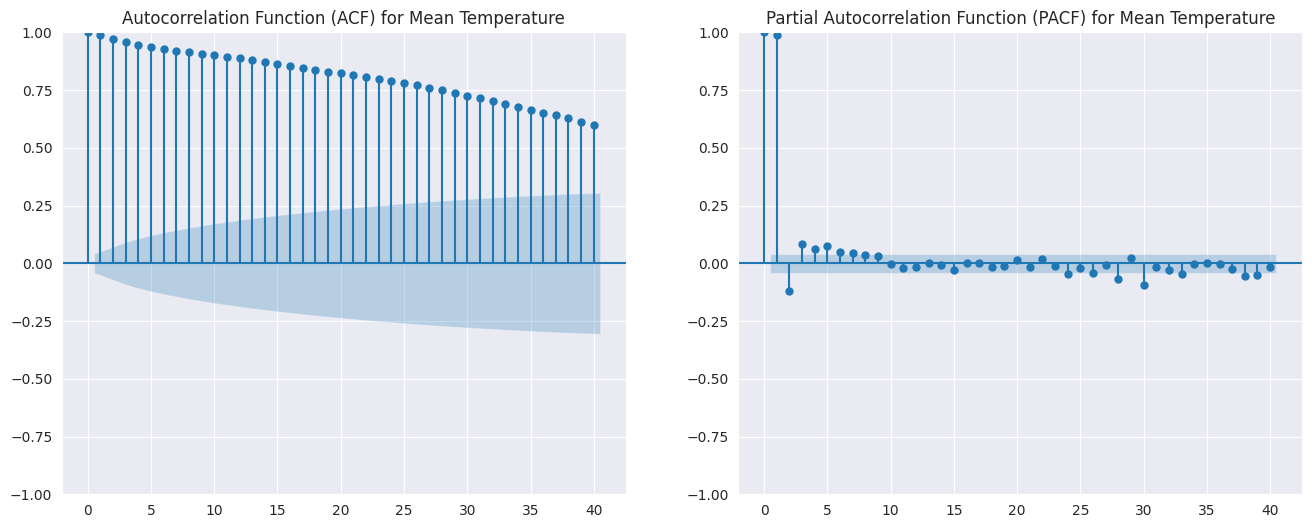

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF
plot_acf(
    df1['meantemp'],
    ax=axes[0],
    lags=40,
    title='Autocorrelation Function (ACF) for Mean Temperature'
)

# PACF
plot_pacf(
    df1['meantemp'],
    ax=axes[1],
    lags=40,
    title='Partial Autocorrelation Function (PACF) for Mean Temperature'
)

plt.show()

The series does not seem stationary, ACF has to become 0 at some point. But we are not sure yet.

Confirming with ADF test...

## ADF Test

To check stationarity, the Dickey-Fuller test is used:

- Null Hypothesis H0: The series is not stationary
- Alternative Hypothesis H1: The series is stationary

## 7.2 Function for ADF test:

In [24]:
def check_stationarity(series):
    print(f'\nChecking Stationarity for: {series.name}\n')

    # drop nulll values
    series = series.dropna()

    adf_test=adfuller(series)

    print('ADF Statistics: %f' % adf_test[0])
    print('p-value: %f' % adf_test[1])
    print('ADF test critical value at 5 percent level of significance: %f' % adf_test[4]['5%'])

    if (adf_test[1] <= 0.05) & (adf_test[0] < adf_test[4]['5%']):
        print('\u001b[32mSince p-value < 0.05, hence series is Stationary.\u001b[0m \n')
    else:
        print('\x1b[31mSince p-value > 0.05, hence series is Non-Stationary.\x1b[0m \n')

In [25]:
# Check initial stationarity for each feature

check_stationarity(df1['meantemp'])
check_stationarity(df1['humidity'])
check_stationarity(df1['wind_speed'])


Checking Stationarity for: meantemp

ADF Statistics: -2.641097
p-value: 0.084797
ADF test critical value at 5 percent level of significance: -2.862865
Since p-value > 0.05, hence series is Non-Stationary. 


Checking Stationarity for: humidity

ADF Statistics: -3.344632
p-value: 0.012998
ADF test critical value at 5 percent level of significance: -2.862864
Since p-value < 0.05, hence series is Stationary. 


Checking Stationarity for: wind_speed

ADF Statistics: -6.084130
p-value: 0.000000
ADF test critical value at 5 percent level of significance: -2.862873
Since p-value < 0.05, hence series is Stationary. 



## 7.3 Applying Differencing to Make the Series Stationary

### Common Methods to Achieve Stationarity

- **Differencing**: Subtract consecutive observations to remove trend and stabilize the mean.
- **Detrending**: Remove the trend component using regression or smoothing techniques.

---

### Other Methods
- **Seasonal Differencing**: Difference observations separated by a seasonal period.
- **Transformation**: Apply log, square root, or Box-Cox to stabilize variance.
- **Smoothing**: Use moving averages or exponential smoothing to reduce noise.
- **Decomposition**: Separate and remove trend and seasonal components.
- **Regression**: Remove effects of exogenous variables using a regression model.

> Methods can be used individually or combined based on data characteristics and analysis goals.


In [26]:
df1['meantemp_diff'] = df1['meantemp'].diff().fillna(0)  # diff() default is 1st degree differencing

print('### After Differencing ###\n')
check_stationarity(df1['meantemp_diff']);

### After Differencing ###


Checking Stationarity for: meantemp_diff

ADF Statistics: -19.431485
p-value: 0.000000
ADF test critical value at 5 percent level of significance: -2.862864
Since p-value < 0.05, hence series is Stationary. 



## 7.4 Interpreting ACF and PACF

### Autocorrelation Function (ACF)
- Measures correlation between a time series and its **lagged values**.
- X-axis: **lag**, Y-axis: **correlation (−1 to 1)**.
- Shaded region represents the **95% confidence interval**; spikes outside are significant.
- Slow decay indicates **trend or non-stationarity**.
- Repeating spikes indicate **seasonality**.
- Used to identify **MA (q)** terms.

---

### Partial Autocorrelation Function (PACF)
- Measures correlation with a lag after **removing effects of intermediate lags**.
- Significant spikes at early lags indicate **direct dependence**.
- Sharp cutoff after lag *k* suggests **AR (p)** order.

---

### Lagged Values
- A lag of *k* refers to the value from **k time steps earlier**.
- Example: lag-1 = previous day, lag-365 = same day last year (daily data).

---

### Model Identification (Rule of Thumb)
- **ACF tails off, PACF cuts off** → AR model  
- **PACF tails off, ACF cuts off** → MA model  
- **Both tail off** → ARMA / ARIMA  
- **Seasonal spikes present** → include seasonal terms


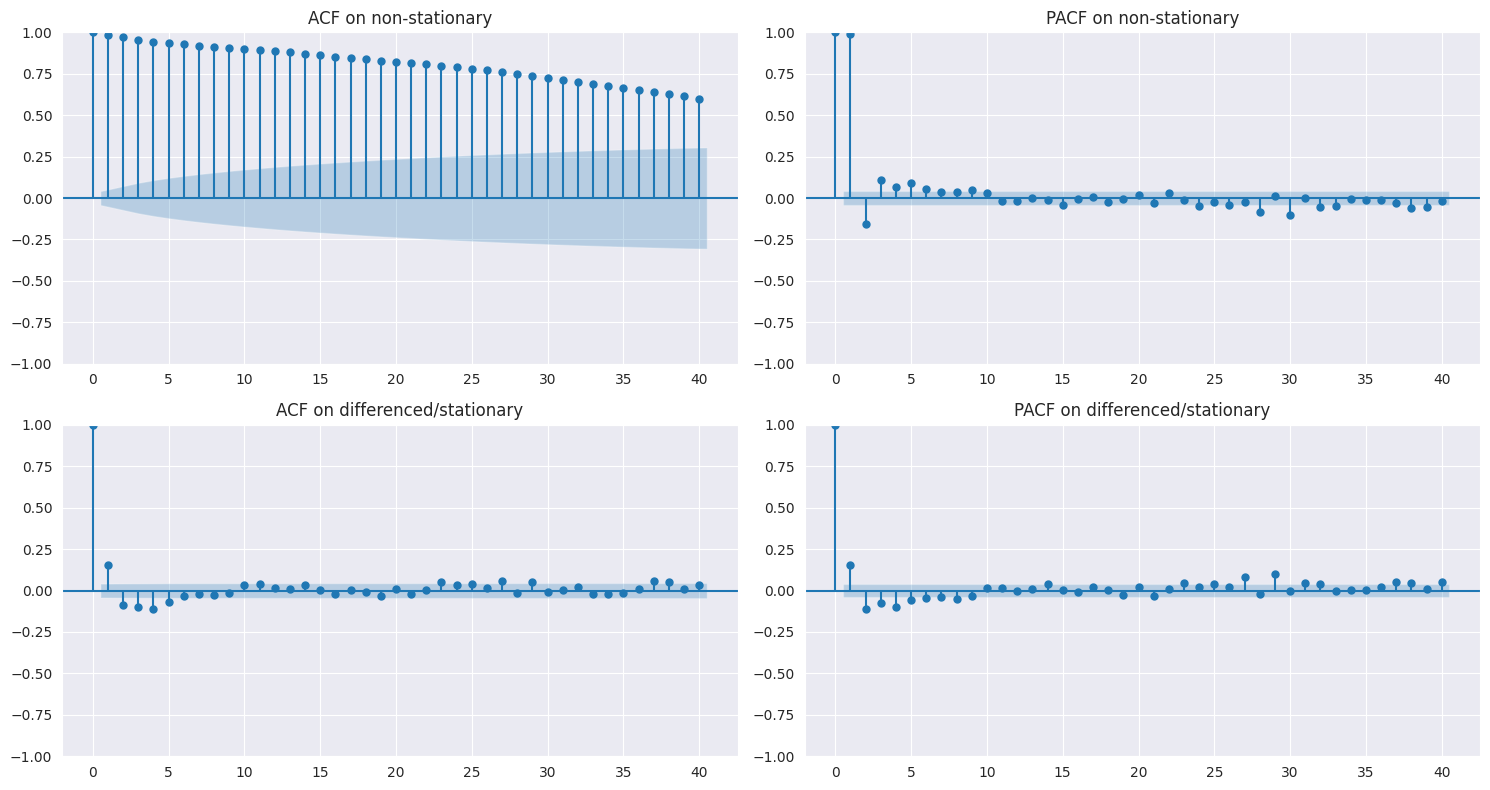

In [27]:
f, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

plot_acf(df1['meantemp'], lags=40, ax=ax[0, 0], title='ACF on non-stationary')
plot_pacf(df1['meantemp'], lags=40, ax=ax[0, 1], method='ols', title='PACF on non-stationary')

plot_acf(df1['meantemp_diff'], lags=40, ax=ax[1, 0], title='ACF on differenced/stationary')
plot_pacf(df1['meantemp_diff'], lags=40, ax=ax[1, 1], method='ols', title='PACF on differenced/stationary')

plt.tight_layout()
plt.show()

After differencing, the series has become stationary

## 7.5 ARIMA-SARIMA with Daily data

## The meaning of p, d and q

- p:
    - p is the order of the Auto Regressive (AR) term. It refers to the number of lags of Y to be used as predictors.
<br>
- d:

    - The term Auto Regressive’ in ARIMA means it is a linear regression model that uses its own lags as predictors. Linear regression models, as we know, work best when the predictors are not correlated and are independent of each other. So we need to make the time series stationary.

    - The most common approach to make the series stationary is to difference it. That is, subtract the previous value from the current value. Sometimes, depending on the complexity of the series, more than one differencing may be needed.

    - The value of d, therefore, is the minimum number of differencing needed to make the series stationary. If the time series is already stationary, then d = 0.
<br>
- q: 
    - q is the order of the Moving Average (MA) term. It refers to the number of lagged forecast errors that should go into the ARIMA Model.

In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2193 entries, 2020-01-01 to 2026-01-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   meantemp       2193 non-null   float64
 1   humidity       2193 non-null   float64
 2   wind_speed     2193 non-null   float64
 3   meantemp_diff  2193 non-null   float64
dtypes: float64(4)
memory usage: 85.7 KB


In [29]:
display(df1.head())
display(df1.tail())

,meantemp,humidity,wind_speed,meantemp_diff
date,,,,
2020-01-01,9.98,82.94,2.09,0.00
2020-01-02,13.44,84.70,2.25,3.46
2020-01-03,14.00,92.51,2.01,0.56
2020-01-04,14.31,85.76,1.95,0.31
2020-01-05,13.15,83.57,3.29,-1.16


,meantemp,humidity,wind_speed,meantemp_diff
date,,,,
2025-12-28,11.85,79.74,2.28,0.05
2025-12-29,11.55,79.65,2.33,-0.30
2025-12-30,12.60,71.29,2.66,1.05
2025-12-31,13.43,64.09,1.70,0.83
2026-01-01,14.21,68.54,1.80,0.78


In [30]:
# Split the data into training and testing sets
train_size = int(len(df1) * 0.8)
train, test = df1.iloc[:train_size], df1.iloc[train_size:]

In [31]:
print(train.shape)
print(test.shape)

(1754, 4)
(439, 4)


### ARIMA Daily - Grid Search for best Parameters (p, d, q)

In [32]:
import itertools

# Set d (based on ADF test)
d = 1

# Define range for p and q
p = range(0, 4)
q = range(0, 4)

# Generate combinations
pdq = list(itertools.product(p, [d], q))

# Fit models and store AIC and MSE
arima_daily_results = []

for param in pdq:
    try:
        arima_daily = ARIMA(train['meantemp'], order=param)
        arima_daily_fit = arima_daily.fit()

        # Forecast on test set
        arima_daily_pred = arima_daily_fit.forecast(steps=len(test))

        # Evaluation metrics
        arima_daily_mse = mean_squared_error(test['meantemp'], arima_daily_pred)

        arima_daily_results.append({
            'order': param,
            'AIC': arima_daily_fit.aic,
            'MSE (ARIMA Daily)':arima_daily_mse,
        })

        print(f"ARIMA{param} - AIC:{arima_daily_fit.aic:.2f}, MSE:{arima_daily_mse:.2f}")

    except:
        continue

# Convert to DataFrame
arima_daily_results_df = pd.DataFrame(arima_daily_results).sort_values(by='MSE (ARIMA Daily)')

print("\nTop Models based on MSE:")
print(arima_daily_results_df.head())

ARIMA(0, 1, 0) - AIC:5135.73, MSE:50.86
ARIMA(0, 1, 1) - AIC:5086.93, MSE:50.85
ARIMA(0, 1, 2) - AIC:5082.40, MSE:50.85
ARIMA(0, 1, 3) - AIC:5070.24, MSE:50.83
ARIMA(1, 1, 0) - AIC:5095.02, MSE:50.86
ARIMA(1, 1, 1) - AIC:5085.45, MSE:50.85
ARIMA(1, 1, 2) - AIC:5048.14, MSE:50.90
ARIMA(1, 1, 3) - AIC:5045.56, MSE:50.89
ARIMA(2, 1, 0) - AIC:5077.03, MSE:50.84
ARIMA(2, 1, 1) - AIC:5040.10, MSE:50.87
ARIMA(2, 1, 2) - AIC:5040.67, MSE:50.86
ARIMA(2, 1, 3) - AIC:5038.93, MSE:50.83
ARIMA(3, 1, 0) - AIC:5068.15, MSE:50.84
ARIMA(3, 1, 1) - AIC:5041.22, MSE:50.86
ARIMA(3, 1, 2) - AIC:5039.66, MSE:50.83
ARIMA(3, 1, 3) - AIC:5040.90, MSE:50.83

Top Models based on MSE:
        order          AIC  MSE (ARIMA Daily)
14  (3, 1, 2)  5039.659575          50.826368
15  (3, 1, 3)  5040.896242          50.826479
11  (2, 1, 3)  5038.926588          50.826567
3   (0, 1, 3)  5070.244514          50.833343
12  (3, 1, 0)  5068.152847          50.838415


## ARIMA Daily - Best Model

In [33]:
arima_daily_top_mse = arima_daily_results_df.nsmallest(5, 'MSE (ARIMA Daily)')
best_idx = arima_daily_top_mse['AIC'].idxmin()

arima_daily_best_model = arima_daily_top_mse.loc[best_idx]
print("\nARIMA Daily Best Model:")
print(arima_daily_best_model)


ARIMA Daily Best Model:
order                  (2, 1, 3)
AIC                  5038.926588
MSE (ARIMA Daily)      50.826567
Name: 11, dtype: object


                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                 1754
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -2513.463
Date:                Tue, 16 Jun 2026   AIC                           5038.927
Time:                        17:58:02   BIC                           5071.741
Sample:                    01-01-2020   HQIC                          5051.056
                         - 10-19-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4730      0.126     11.647      0.000       1.225       1.721
ar.L2         -0.6642      0.089     -7.477      0.000      -0.838      -0.490
ma.L1         -1.3301      0.128    -10.405      0.0

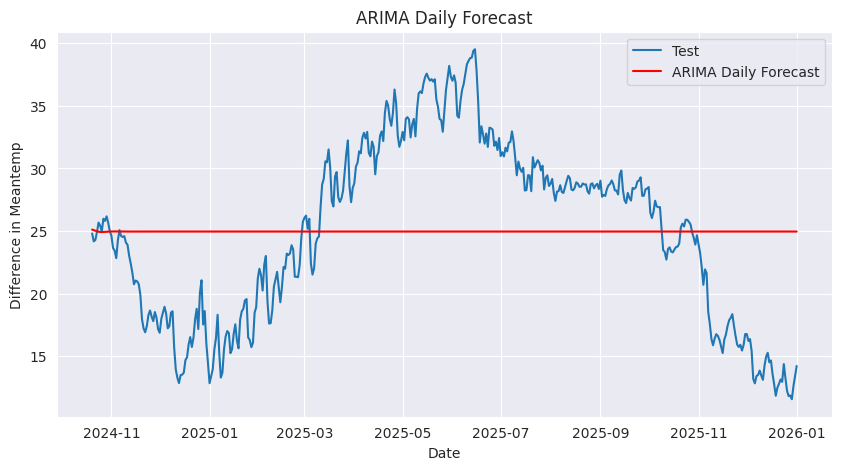

In [34]:
# ARIMA Daily

arima_daily_order = arima_daily_best_model['order']

# Fit the ARIMA model
arima_daily = ARIMA(train['meantemp'], order=arima_daily_order)
arima_daily_fit = arima_daily.fit()
print(arima_daily_fit.summary())

# Make predictions
arima_daily_pred = arima_daily_fit.forecast(steps=len(test))

# Calculate error
arima_daily_mse = mean_squared_error(test['meantemp'], arima_daily_pred)
arima_daily_r2 = r2_score(test['meantemp'], arima_daily_pred)
print('Test MSE (ARIMA Daily): %.3f' % arima_daily_mse)
print('R2 Score (ARIMA Daily): %.3f'% arima_daily_r2)


# Plot the results
plt.figure(figsize=(10,5))
# plt.plot(train.index, train['meantemp'], label='Train')
plt.plot(test.index, test['meantemp'], label='Test')
plt.plot(test.index, arima_daily_pred, color='red', label='ARIMA Daily Forecast')
plt.xlabel('Date')
plt.ylabel('Difference in Meantemp')
plt.title('ARIMA Daily Forecast')
plt.legend()
plt.show()

## Residual - ARIMA Daily

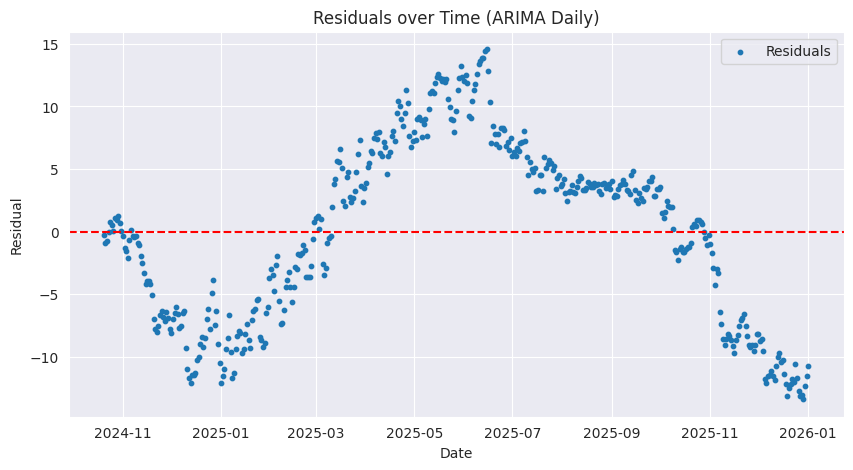

In [35]:
arima_daily_residuals = test['meantemp'] - arima_daily_pred

plt.figure(figsize=(10,5))
plt.scatter(test.index, arima_daily_residuals, s=10, label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals over Time (ARIMA Daily)')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.show()

The residual plot shows clear cyclical patterns and is not randomly distributed around zero, indicating that the model fails to capture underlying seasonality. The ACF plot also exhibits strong autocorrelation across multiple lags, confirming that residuals are not independent. Hence, the ARIMA model is inadequate for this dataset and a seasonal model such as SARIMA is more appropriate.

### SARIMA Daily - Grid Search for Best Parameters [Non Seasonal : (p, d, q), Seasonal : (P, D, Q, s)]

In [36]:
# SARIMA Daily

d = D = 1
# Non-seasonal parameters
p = q = range(1, 3)

# Seasonal parameters
P = Q = range(1, 3)
s = 7   # weekly seasonality

pdq = list(itertools.product(p, [d], q))

# Generate Combinations
seasonal_pdq = list(itertools.product(P, [D], Q, [s]))

# Fit models and store AIC, BIC and MSE
sarima_daily_results = []

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            sarima_daily = SARIMAX(train['meantemp'],
                            order=param,
                            seasonal_order=seasonal_param)
            
            sarima_daily_fit = sarima_daily.fit(disp=False) 
            
            # Forecast on train set
            sarima_daily_pred = sarima_daily_fit.forecast(steps=len(test))

            # Evaluation metrics
            sarima_daily_mse = mean_squared_error(test['meantemp'], sarima_daily_pred)

            sarima_daily_results.append({
                'order':param,
                'seasonal_order':seasonal_param,
                'AIC':sarima_daily_fit.aic,
                'MSE (SARIMA Daily)':sarima_daily_mse
            })

            print(f"SARIMA{param}x{seasonal_param} - AIC:{sarima_daily_fit.aic:.2f}, MSE:{sarima_daily_mse:.2f}")

        except:
            continue

# Convert to DataFrame
sarima_daily_results_df = pd.DataFrame(sarima_daily_results).sort_values(by='MSE (SARIMA Daily)')

print("\nTop Models:")
print(sarima_daily_results_df.head())

SARIMA(1, 1, 1)x(1, 1, 1, 7) - AIC:5109.83, MSE:55.98
SARIMA(1, 1, 1)x(1, 1, 2, 7) - AIC:5106.38, MSE:55.95
SARIMA(1, 1, 1)x(2, 1, 1, 7) - AIC:5107.91, MSE:55.44
SARIMA(1, 1, 1)x(2, 1, 2, 7) - AIC:5108.23, MSE:56.01
SARIMA(1, 1, 2)x(1, 1, 1, 7) - AIC:5073.09, MSE:55.76
SARIMA(1, 1, 2)x(1, 1, 2, 7) - AIC:5070.55, MSE:55.67
SARIMA(1, 1, 2)x(2, 1, 1, 7) - AIC:5069.84, MSE:55.24
SARIMA(1, 1, 2)x(2, 1, 2, 7) - AIC:5071.61, MSE:55.76
SARIMA(2, 1, 1)x(1, 1, 1, 7) - AIC:5064.68, MSE:55.43
SARIMA(2, 1, 1)x(1, 1, 2, 7) - AIC:5062.18, MSE:55.34
SARIMA(2, 1, 1)x(2, 1, 1, 7) - AIC:5061.79, MSE:54.89
SARIMA(2, 1, 1)x(2, 1, 2, 7) - AIC:5063.34, MSE:55.41
SARIMA(2, 1, 2)x(1, 1, 1, 7) - AIC:5109.45, MSE:63.54
SARIMA(2, 1, 2)x(1, 1, 2, 7) - AIC:5106.10, MSE:63.43
SARIMA(2, 1, 2)x(2, 1, 1, 7) - AIC:5106.63, MSE:63.26
SARIMA(2, 1, 2)x(2, 1, 2, 7) - AIC:5107.74, MSE:63.52

Top Models:
        order seasonal_order          AIC  MSE (SARIMA Daily)
10  (2, 1, 1)   (2, 1, 1, 7)  5061.789250           54.892014

## SARIMA Daily - Best Model

In [37]:
sarima_daily_top_mse = sarima_daily_results_df.nsmallest(5, 'MSE (SARIMA Daily)')
best_idx = sarima_daily_top_mse['AIC'].idxmin()

sarima_daily_best_model = sarima_daily_top_mse.loc[best_idx]
print("\nSARIMA Daily Best Model:")
print(sarima_daily_best_model)


SARIMA Daily Best Model:
order                    (2, 1, 1)
seasonal_order        (2, 1, 1, 7)
AIC                     5061.78925
MSE (SARIMA Daily)       54.892014
Name: 10, dtype: object


                                     SARIMAX Results                                     
Dep. Variable:                          meantemp   No. Observations:                 1754
Model:             SARIMAX(2, 1, 1)x(2, 1, 1, 7)   Log Likelihood               -2356.062
Date:                           Tue, 16 Jun 2026   AIC                           4730.123
Time:                                   17:59:54   BIC                           4779.309
Sample:                               01-01-2020   HQIC                          4748.307
                                    - 10-19-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
humidity      -0.0706      0.003    -25.884      0.000      -0.076      -0.065
wind_speed    -0.1589      0.020     -7.898

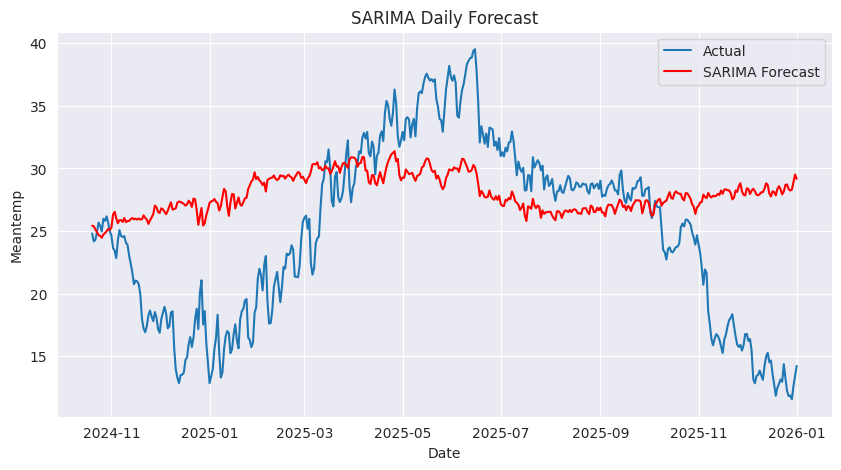

In [38]:
# SARIMA Daily

non_seasonal_order = sarima_daily_best_model['order']
seasonal_order = sarima_daily_best_model['seasonal_order']

# Fit the SARIMA model
sarima_daily = SARIMAX(endog=train['meantemp'], exog=train[['humidity', 'wind_speed']],
                       order=non_seasonal_order, seasonal_order=seasonal_order)
sarima_daily_fit = sarima_daily.fit()
print(sarima_daily_fit.summary())

# Make predictions
sarima_daily_pred = sarima_daily_fit.predict(start=test.index[0], end=test.index[-1],
                                        exog=test[['humidity', 'wind_speed']])

# Calculate error
sarima_daily_mse = mean_squared_error(test['meantemp'], sarima_daily_pred)
sarima_daily_r2 = r2_score(test['meantemp'], sarima_daily_pred)
print('Test MSE (SARIMA Daily): %.3f'% sarima_daily_mse)
print('R2 Score (SARIMA Daily): %.3f'% sarima_daily_r2)

# Plot the results
plt.figure(figsize=(10, 5))
# plt.plot(train.index, train['meantemp'], label='Train')
plt.plot(test.index, test['meantemp'], label='Actual')
plt.plot(test.index, sarima_daily_pred, color='red', label='SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.title('SARIMA Daily Forecast')
plt.legend()
plt.show()

## Residuals- SARIMA Daily

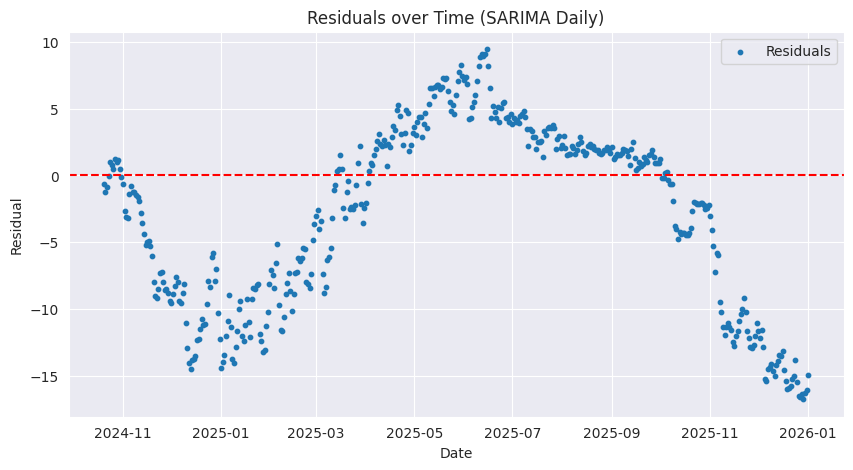

In [39]:
sarima_daily_residuals = test['meantemp'] - sarima_daily_pred

plt.figure(figsize=(10,5))
plt.scatter(test.index, sarima_daily_residuals, s=10, label = 'Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals over Time (SARIMA Daily)')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.show()

For daily predictions, using a seasonality parameter of 365 is impractical as it significantly increases the model's computation time. Instead, we will aggregate the data to monthly values for predictions.

## 7.6 ARIMA-SARIMA with Monthly data

In [40]:
monthly_df = df1.resample('M',).mean()

# Split the data into training and testing sets
train_size = int(len(monthly_df) * 0.8)
m_train, m_test = monthly_df.iloc[:train_size], monthly_df.iloc[train_size:]

### ARIMA Monthly

In [41]:
# set d based on ADF Test
d = 1
# Define range for p and q
p = range(0, 4)
q = range(0, 4)

# Generate combinations
pdq = list(itertools.product(p, [d], q))

arima_mon_results = []

for param in pdq:
    try:
        arima_mon = ARIMA(m_train['meantemp'], order=param)
        arima_mon_fit = arima_mon.fit()

        arima_mon_pred = arima_mon_fit.forecast(steps=len(m_test))
        arima_mon_pred = pd.Series(arima_mon_pred, index=m_test.index)

        arima_mon_mse = mean_squared_error(m_test['meantemp'], arima_mon_pred)

        arima_mon_results.append({
            'order': param,
            'AIC' : arima_mon_fit.aic,
            'MSE (ARIMA Monthly)': arima_mon_mse
        })

        print(f"ARIMA{param} - AIC:{arima_mon_fit.aic:.2f}, MSE:{arima_mon_mse:.2f}")

    except:
        continue

# Convert to DataFrame
arima_mon_results_df = pd.DataFrame(arima_mon_results).sort_values(by='MSE (ARIMA Monthly)')

print("\nTop Models:")
print(arima_mon_results_df.head())


ARIMA(0, 1, 0) - AIC:323.02, MSE:54.70
ARIMA(0, 1, 1) - AIC:296.37, MSE:53.62
ARIMA(0, 1, 2) - AIC:290.89, MSE:58.12
ARIMA(0, 1, 3) - AIC:289.18, MSE:60.59
ARIMA(1, 1, 0) - AIC:295.72, MSE:60.71
ARIMA(1, 1, 1) - AIC:292.10, MSE:55.69
ARIMA(1, 1, 2) - AIC:291.88, MSE:62.76
ARIMA(1, 1, 3) - AIC:290.85, MSE:58.36
ARIMA(2, 1, 0) - AIC:287.30, MSE:49.99
ARIMA(2, 1, 1) - AIC:270.61, MSE:41.10
ARIMA(2, 1, 2) - AIC:272.47, MSE:40.00
ARIMA(2, 1, 3) - AIC:288.84, MSE:52.88
ARIMA(3, 1, 0) - AIC:285.65, MSE:49.73
ARIMA(3, 1, 1) - AIC:272.52, MSE:40.47
ARIMA(3, 1, 2) - AIC:274.20, MSE:39.64
ARIMA(3, 1, 3) - AIC:276.19, MSE:39.45

Top Models:
        order         AIC  MSE (ARIMA Monthly)
15  (3, 1, 3)  276.188719            39.451921
14  (3, 1, 2)  274.200517            39.639918
10  (2, 1, 2)  272.474237            40.003921
13  (3, 1, 1)  272.516282            40.466057
9   (2, 1, 1)  270.611851            41.097291


In [42]:
arima_mon_top_mse = arima_mon_results_df.nsmallest(5, 'MSE (ARIMA Monthly)')
best_idx = arima_mon_top_mse['AIC'].idxmin()

arima_mon_best_model = arima_mon_top_mse.loc[best_idx]

print("\nARIMA Monthly Best Model:")
print(arima_mon_best_model)


ARIMA Monthly Best Model:
order                   (2, 1, 1)
AIC                    270.611851
MSE (ARIMA Monthly)     41.097291
Name: 9, dtype: object


Best Order: (2, 1, 1)
Test MSE (ARIMA Monthly): 41.097
R2 Score (ARIMA Monthly): 0.211


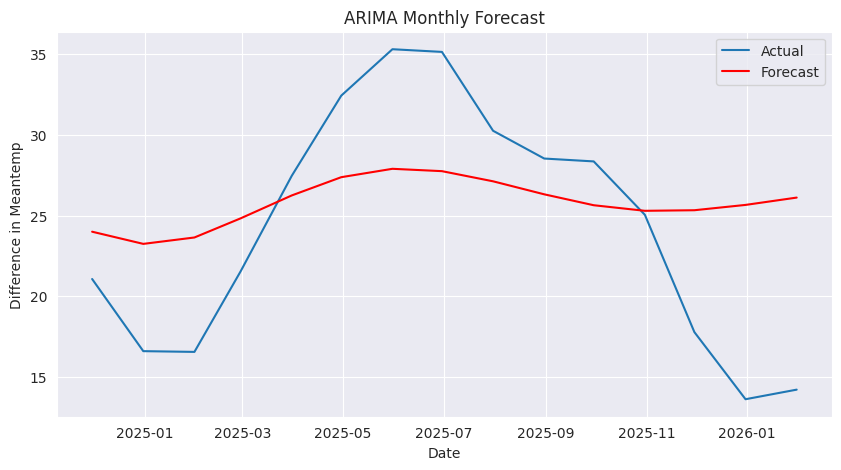

In [43]:
# ARIMA Monthly

arima_mon_order = arima_mon_best_model['order']
print("Best Order:", arima_mon_order)

# Fit the ARIMA model
arima_mon = ARIMA(m_train['meantemp'], order=arima_mon_order)  # ARIMA(p,d,q)
arima_mon_fit = arima_mon.fit()

# Make predictions
arima_mon_pred = arima_mon_fit.forecast(steps=len(m_test))

# Calculate error
arima_mon_mse = mean_squared_error(m_test['meantemp'], arima_mon_pred)
arima_mon_r2 = r2_score(m_test['meantemp'], arima_mon_pred)
print('Test MSE (ARIMA Monthly): %.3f' % arima_mon_mse)
print('R2 Score (ARIMA Monthly): %.3f' % arima_mon_r2)

# Plot the results
plt.figure(figsize=(10, 5))
# plt.plot(m_train.index, m_train['meantemp'], label='Train')
plt.plot(m_test.index, m_test['meantemp'], label='Actual')
plt.plot(m_test.index, arima_mon_pred, color='red', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Difference in Meantemp')
plt.title('ARIMA Monthly Forecast')
plt.legend()
plt.show()

### SARIMA Monthly

In [44]:
# Define parameter ranges
p = d = q = range(0, 2)
P = D = Q = range(0, 2)
s = 12  # monthly data

pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, [s]))

sarima_mon_results = []

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            sarima_mon = SARIMAX(m_train['meantemp'],
                            order=param,
                            seasonal_order=seasonal_param,
                            enforce_stationarity=False,
                            enforce_invertibility=False)

            sarima_mon_fit = sarima_mon.fit(disp=False)

            # Forecast
            sarima_mon_pred = sarima_mon_fit.forecast(steps=len(m_test))
            sarima_mon_pred = pd.Series(sarima_mon_pred, index=m_test.index)

            # MSE
            sarima_mon_mse = mean_squared_error(m_test['meantemp'], sarima_mon_pred)

            sarima_mon_results.append({
                'order': param,
                'seasonal_order': seasonal_param,
                'AIC': sarima_mon_fit.aic,
                'MSE (SARIMA Monthly)': sarima_mon_mse
            })

            print(f"SARIMA{param}x{seasonal_param} - AIC:{sarima_mon_fit.aic:.2f}, MSE:{sarima_mon_mse:.2f}")

        except:
            continue

# Convert to DataFrame
sarima_mon_results_df = pd.DataFrame(sarima_mon_results)

# Sort by MSE (important)
sarima_mon_results_df = sarima_mon_results_df.sort_values(by='MSE (SARIMA Monthly)')

print("\nTop SARIMA Models:")
print(sarima_mon_results_df.head())

SARIMA(0, 0, 0)x(0, 0, 0, 12) - AIC:540.93, MSE:640.66
SARIMA(0, 0, 0)x(0, 0, 1, 12) - AIC:395.57, MSE:238.94
SARIMA(0, 0, 0)x(0, 1, 0, 12) - AIC:201.53, MSE:5.01
SARIMA(0, 0, 0)x(0, 1, 1, 12) - AIC:1157.20, MSE:5.01
SARIMA(0, 0, 0)x(1, 0, 0, 12) - AIC:208.75, MSE:6.30
SARIMA(0, 0, 0)x(1, 0, 1, 12) - AIC:191.68, MSE:3.66
SARIMA(0, 0, 0)x(1, 1, 0, 12) - AIC:141.51, MSE:3.35
SARIMA(0, 0, 0)x(1, 1, 1, 12) - AIC:1295.26, MSE:3.38
SARIMA(0, 0, 1)x(0, 0, 0, 12) - AIC:463.76, MSE:611.63
SARIMA(0, 0, 1)x(0, 0, 1, 12) - AIC:334.92, MSE:216.00
SARIMA(0, 0, 1)x(0, 1, 0, 12) - AIC:167.05, MSE:5.72
SARIMA(0, 0, 1)x(0, 1, 1, 12) - AIC:1023.63, MSE:6.58
SARIMA(0, 0, 1)x(1, 0, 0, 12) - AIC:180.83, MSE:7.06
SARIMA(0, 0, 1)x(1, 0, 1, 12) - AIC:189.40, MSE:3.60
SARIMA(0, 0, 1)x(1, 1, 0, 12) - AIC:129.03, MSE:3.76
SARIMA(0, 0, 1)x(1, 1, 1, 12) - AIC:1107.36, MSE:4.20
SARIMA(0, 1, 0)x(0, 0, 0, 12) - AIC:317.78, MSE:54.70
SARIMA(0, 1, 0)x(0, 0, 1, 12) - AIC:228.33, MSE:24.67
SARIMA(0, 1, 0)x(0, 1, 0, 12) - 

In [45]:
sarima_mon_top_mse = sarima_mon_results_df.nsmallest(5, 'MSE (SARIMA Monthly)')
best_idx = sarima_mon_top_mse['AIC'].idxmin()

sarima_mon_best_model = sarima_mon_top_mse.loc[best_idx]
print("\nSARIMA Monthly Best Model:")
print(sarima_mon_best_model)


SARIMA Monthly Best Model:
order                       (1, 0, 0)
seasonal_order          (1, 1, 0, 12)
AIC                        127.155574
MSE (SARIMA Monthly)         3.482246
Name: 38, dtype: object


                                     SARIMAX Results                                      
Dep. Variable:                           meantemp   No. Observations:                   58
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood                 -52.399
Date:                            Tue, 16 Jun 2026   AIC                            114.797
Time:                                    18:00:03   BIC                            123.940
Sample:                                01-31-2020   HQIC                           118.222
                                     - 10-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
humidity      -0.1417      0.011    -13.305      0.000      -0.163      -0.121
wind_speed     0.0696      0.292   

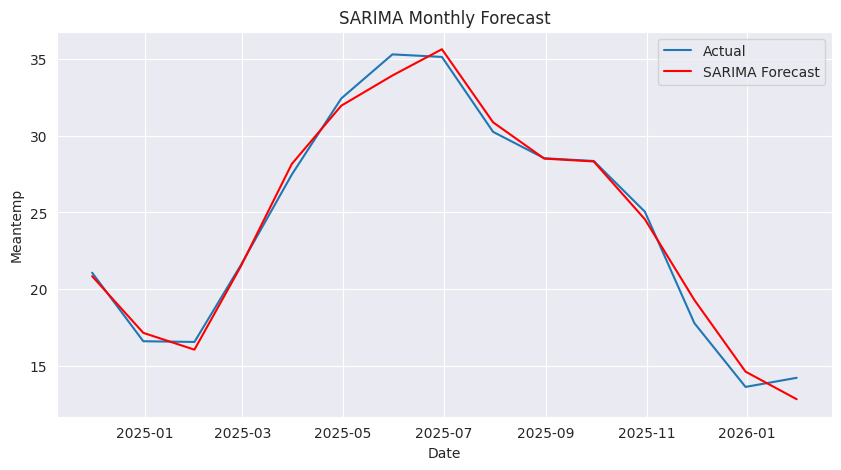

In [46]:
# SARIMA Monthly

non_seasonal_order = sarima_mon_best_model['order']
seasonal_order = sarima_mon_best_model['seasonal_order']

# Fit the SARIMA model
sarima_mon = SARIMAX(endog=m_train['meantemp'], exog=m_train[['humidity', 'wind_speed']],
                       order=non_seasonal_order, seasonal_order=seasonal_order)
sarima_mon_fit = sarima_mon.fit()
print(sarima_mon_fit.summary())

# Make predictions
sarima_mon_pred = sarima_mon_fit.predict(start=m_test.index[0], end=m_test.index[-1],
                                        exog=m_test[['humidity', 'wind_speed']])

# Calculate error
sarima_mon_mse = mean_squared_error(m_test['meantemp'], sarima_mon_pred)
sarima_mon_r2 = r2_score(m_test['meantemp'], sarima_mon_pred)
print('Test MSE (SARIMA Monthly): %.3f' % sarima_mon_mse)
print('R2 Score (SARIMA Monthly): %.3f' % sarima_mon_r2)

# Plot the results
plt.figure(figsize=(10, 5))
# plt.plot(m_train.index, m_train['meantemp'], label='Train')
plt.plot(m_test.index, m_test['meantemp'], label='Actual')
plt.plot(m_test.index, sarima_mon_pred, color='red', label='SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.title('SARIMA Monthly Forecast')
plt.legend()
plt.show()

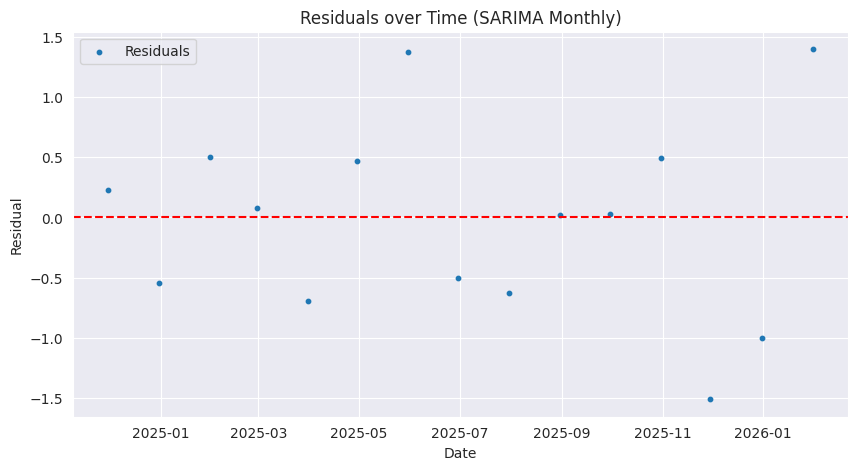

In [47]:
sarima_mon_residuals = m_test['meantemp'] - sarima_mon_pred

plt.figure(figsize=(10,5))
plt.scatter(m_test.index, sarima_mon_residuals, s=10, label = 'Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals over Time (SARIMA Monthly)')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.show()

## 7.7 Modeling with auto_arima

Auto ARIMA:
The auto_arima function will automatically search through combinations of these parameters within the specified ranges to find the best-fitting model based on criteria like AIC (Akaike Information Criterion). By setting these maximum values (max_p, max_d, max_q, max_P, max_D, max_Q), we are specifying the bounds within which auto_arima will search.

In [48]:
from pmdarima import auto_arima

# Fit the model on the training data with optimized settings for monthly seasonality
auto_arima_mon = auto_arima(
    m_train['meantemp'], 
    seasonal=True, 
    m=12,
    max_p=7, 
    max_d=1, 
    max_q=3, 
    max_P=3, 
    max_D=1, 
    max_Q=2,
    trace=True,    # To print the progress of the fitting
    error_action='ignore',  # Ignore potential errors
    suppress_warnings=True,  # Suppress warnings
    n_jobs=-1  # Use all available CPU cores
)

# Print model summary
print(auto_arima_mon.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=208.201, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=178.671, Time=0.08 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=177.970, Time=0.09 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=207.986, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=180.374, Time=0.04 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=178.182, Time=0.17 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=178.306, Time=0.24 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=176.557, Time=0.10 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=178.153, Time=0.20 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=180.145, Time=0.42 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=196.123, Time=0.06 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=176.207, Time=0.12 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=178.499, Time=0.06 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   

R^2 score: 0.926290739301262
RMSE: 1.9594866059179707


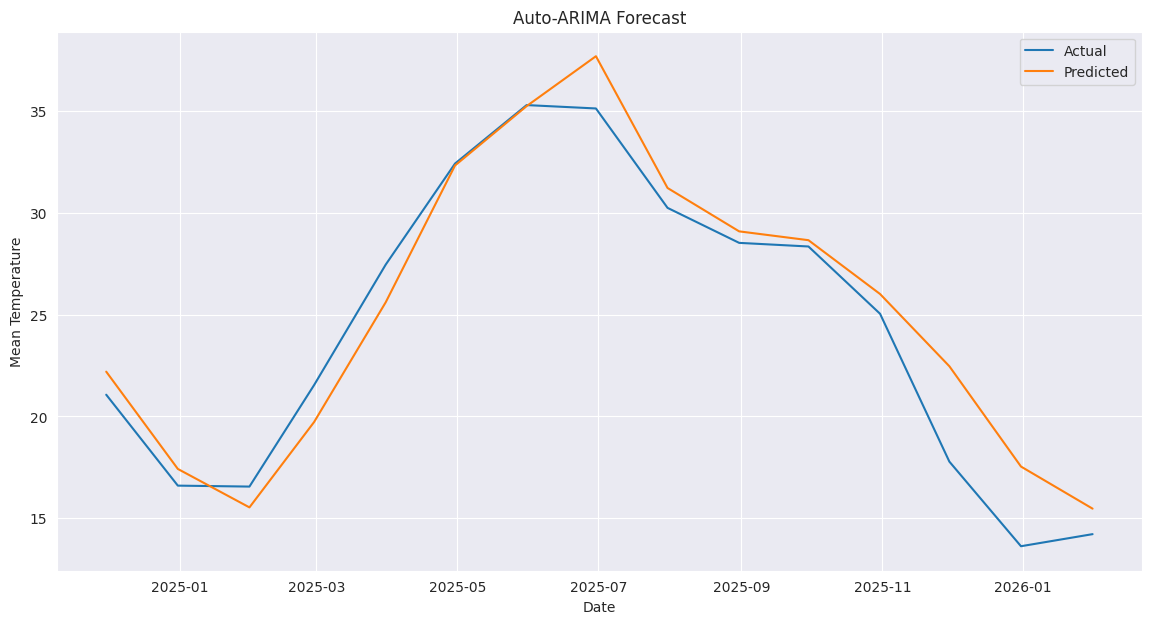

In [49]:
# Make predictions
n_periods = len(m_test)
auto_arima_pred = auto_arima_mon.predict(n_periods=n_periods)

# Calculate R^2 and RMSE
r2 = r2_score(m_test['meantemp'], auto_arima_pred)
rmse = np.sqrt(mean_squared_error(m_test['meantemp'], auto_arima_pred))

print(f'R^2 score: {r2}')
print(f'RMSE: {rmse}')

# Plot the results
plt.figure(figsize=(14, 7))
# plt.plot(m_train.index, m_train['meantemp'], label='Train')
plt.plot(m_test.index, m_test['meantemp'], label='Actual')
plt.plot(m_test.index, auto_arima_pred, label='Predicted')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Auto-ARIMA Forecast')
plt.show()

# 8. Prophet Model
Prophet algorithm works with the "ds" and "y" variables as inputs. We will adjust our training and test sets accordingly.

- ds: This column contains the dates. In Prophet, the dates in this column are typically in daily frequency, although this is not mandatory. The dates can be in the format YYYY-MM-DD (e.g., "2021-01-01") or in timestamp format.

- y: This column contains the observed values we want to predict. For example, if we want to forecast the daily number of visitors to a website, the "y" column will contain these visitor numbers.

------

- yhat: This is the main value predicted by the model. In other words, it is the value that your model predicts the time series will be for a specific "ds" (date) value.

- yhat_lower and yhat_upper: These values represent the uncertainty interval of the predictions. Prophet takes into account uncertainty when making predictions, estimating with high confidence that the true value will fall within this range. For example, if yhat_lower is 50 and yhat_upper is 60, it means that the model confidently predicts that the true value will be within this range.

In [50]:
df.head()

,meantemp,humidity,wind_speed
date,,,
2020-01-01,9.98,82.94,2.09
2020-01-02,13.44,84.70,2.25
2020-01-03,14.00,92.51,2.01
2020-01-04,14.31,85.76,1.95
2020-01-05,13.15,83.57,3.29


## 8.1 Prophet Model without other features (humidity, wind_speed)

In [51]:
from prophet import Prophet

In [52]:
df_prophet = df.reset_index().rename(columns = {'date':'ds', 'meantemp':'y'})

train_size = int(len(df_prophet) * 0.8)
p_train = df_prophet.iloc[:train_size].copy() 
p_test = df_prophet.iloc[train_size:].copy()

In [53]:
df_prophet.head()

,ds,y,humidity,wind_speed
0,2020-01-01,9.98,82.94,2.09
1,2020-01-02,13.44,84.70,2.25
2,2020-01-03,14.00,92.51,2.01
3,2020-01-04,14.31,85.76,1.95
4,2020-01-05,13.15,83.57,3.29


In [54]:
# Initialize and fit prophet model without additional features
prophet_model = Prophet(yearly_seasonality = True, weekly_seasonality = True)

prophet_model.fit(p_train)

# Make future dataframe without including additional features
future = prophet_model.make_future_dataframe(periods=int(len(p_test)), freq='D')

18:00:12 - cmdstanpy - INFO - Chain [1] start processing
18:00:12 - cmdstanpy - INFO - Chain [1] done processing


Test MSE: 4.296
Test R²: 0.915


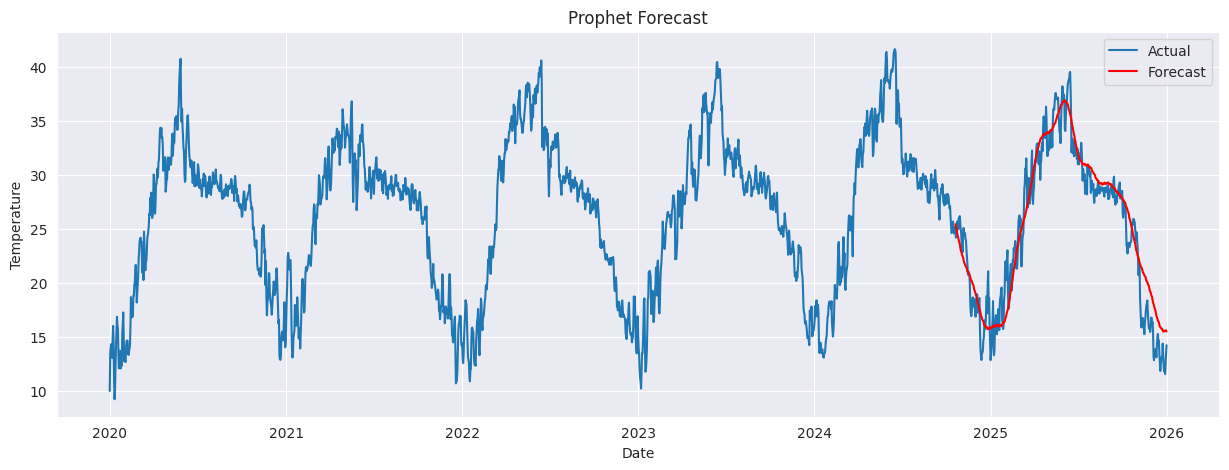

In [55]:
# Make Predictions
prop_forecast = prophet_model.predict(future)

# Extract the forecasted values for the test period
prop_predicted = prop_forecast[['ds', 'yhat']].set_index('ds').loc[p_test['ds']]

# Calculate error and R2
prop_mse = mean_squared_error(p_test['y'], prop_predicted['yhat'])
prop_r2 = r2_score(p_test['y'], prop_predicted['yhat'])
print('Test MSE: %.3f' % prop_mse)
print('Test R²: %.3f' % prop_r2)

# Plot the results
plt.figure(figsize=(15, 5))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual')
plt.plot(prop_predicted.index, prop_predicted['yhat'], color='red', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Prophet Forecast')
plt.legend()
plt.show()

## 8.2 Prophet Model Using entire dataset

In [56]:
# Rename columns for Prophet
df_prophet = df.reset_index().rename(columns={'date': 'ds', 'meantemp': 'y'})

# Add additional features
df_prophet['humidity'] = df['humidity'].values
df_prophet['wind_speed'] = df['wind_speed'].values

# Split the data into training and testing sets
train_size = int(len(df_prophet) * 0.8)
p_train = df_prophet.iloc[:train_size].copy() 
p_test = df_prophet.iloc[train_size:].copy()

In [57]:
# Initialize and fit prophet model without additional features
prophet_model = Prophet(yearly_seasonality = True, weekly_seasonality = True)

# Add additional features
prophet_model.add_regressor('humidity')
prophet_model.add_regressor('wind_speed')

# Fit the model
prophet_model.fit(p_train)

18:00:13 - cmdstanpy - INFO - Chain [1] start processing
18:00:13 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
# Make future dataframe without including additional features
future = prophet_model.make_future_dataframe(periods=int(len(p_test)), freq='D')
future['humidity'] = df['humidity'].values
future['wind_speed'] = df['wind_speed'].values

# Make predicitions
forecast = prophet_model.predict(future)

# Extract the forecasted values for the test period
predicted = forecast[['ds', 'yhat']].set_index('ds').loc[p_test['ds']]

Test MSE: 4.153
Test R²: 0.918


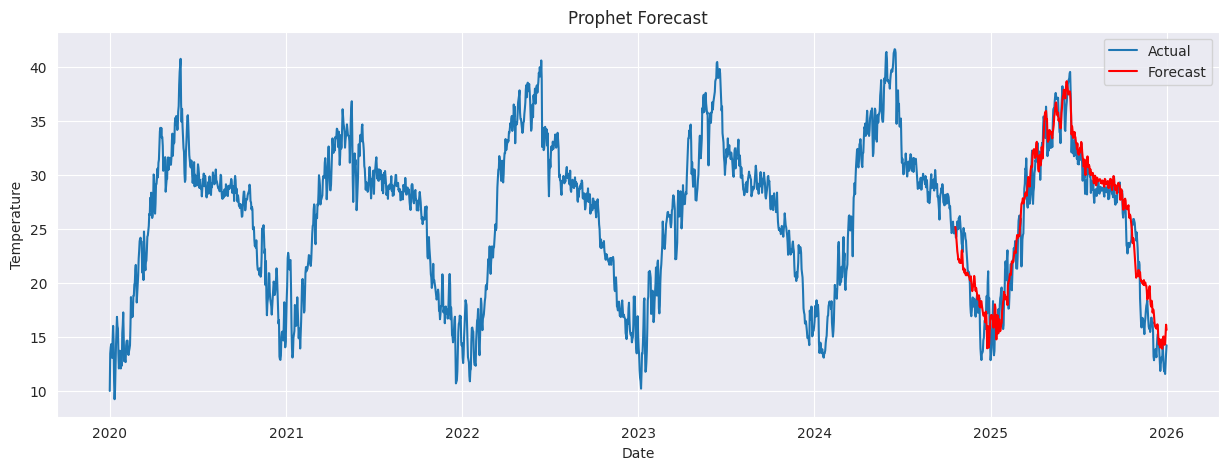

In [59]:
# Calculate error and R2
mse = mean_squared_error(p_test['y'], predicted['yhat'])
r2 = r2_score(p_test['y'], predicted['yhat'])
print('Test MSE: %.3f' % mse)
print('Test R²: %.3f' % r2)

# Plot the results
plt.figure(figsize=(15, 5))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Actual')
plt.plot(predicted.index, predicted['yhat'], color='red', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Prophet Forecast')
plt.legend()
plt.show()

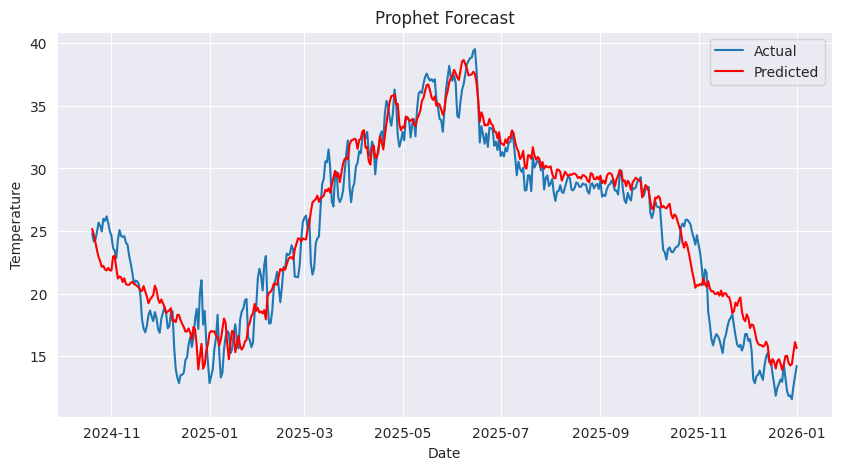

In [60]:
# Looking closer to the result
plt.figure(figsize=(10,5))
plt.plot(p_test['ds'], p_test['y'], label = 'Actual')
plt.plot(predicted.index, predicted['yhat'], color = 'Red', label = 'Predicted')
plt.legend()
plt.title('Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

In [61]:
display(df_prophet.head()) # actual data
display(predicted.head()) # predicted values of p_test

,ds,y,humidity,wind_speed
0,2020-01-01,9.98,82.94,2.09
1,2020-01-02,13.44,84.70,2.25
2,2020-01-03,14.00,92.51,2.01
3,2020-01-04,14.31,85.76,1.95
4,2020-01-05,13.15,83.57,3.29


,yhat
ds,
2024-10-20,25.160235
2024-10-21,24.743128
2024-10-22,24.105694
2024-10-23,23.481703
2024-10-24,22.912110


## Confidence Interval

In [62]:
forecast.head(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,wind_speed,wind_speed_lower,wind_speed_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,25.781663,10.532633,14.760515,25.781663,25.781663,-13.059035,-13.059035,-13.059035,-2.759691,...,0.084082,0.084082,0.084082,-10.306936,-10.306936,-10.306936,0.0,0.0,0.0,12.722628
1,2020-01-02,25.782221,10.330201,14.624487,25.782221,25.782221,-13.258022,-13.258022,-13.258022,-2.966978,...,0.069183,0.069183,0.069183,-10.300520,-10.300520,-10.300520,0.0,0.0,0.0,12.524199
2,2020-01-03,25.782778,9.478915,13.908196,25.782778,25.782778,-14.080103,-14.080103,-14.080103,-3.798349,...,0.091532,0.091532,0.091532,-10.297938,-10.297938,-10.297938,0.0,0.0,0.0,11.702675


In [63]:
# Adding the actual temperature values to forecast data
forecast['Actual_temp'] = df_prophet['y']

forecast.head(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,wind_speed_lower,wind_speed_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,Actual_temp
0,2020-01-01,25.781663,10.532633,14.760515,25.781663,25.781663,-13.059035,-13.059035,-13.059035,-2.759691,...,0.084082,0.084082,-10.306936,-10.306936,-10.306936,0.0,0.0,0.0,12.722628,9.98
1,2020-01-02,25.782221,10.330201,14.624487,25.782221,25.782221,-13.258022,-13.258022,-13.258022,-2.966978,...,0.069183,0.069183,-10.300520,-10.300520,-10.300520,0.0,0.0,0.0,12.524199,13.44
2,2020-01-03,25.782778,9.478915,13.908196,25.782778,25.782778,-14.080103,-14.080103,-14.080103,-3.798349,...,0.091532,0.091532,-10.297938,-10.297938,-10.297938,0.0,0.0,0.0,11.702675,14.00


<Axes: >

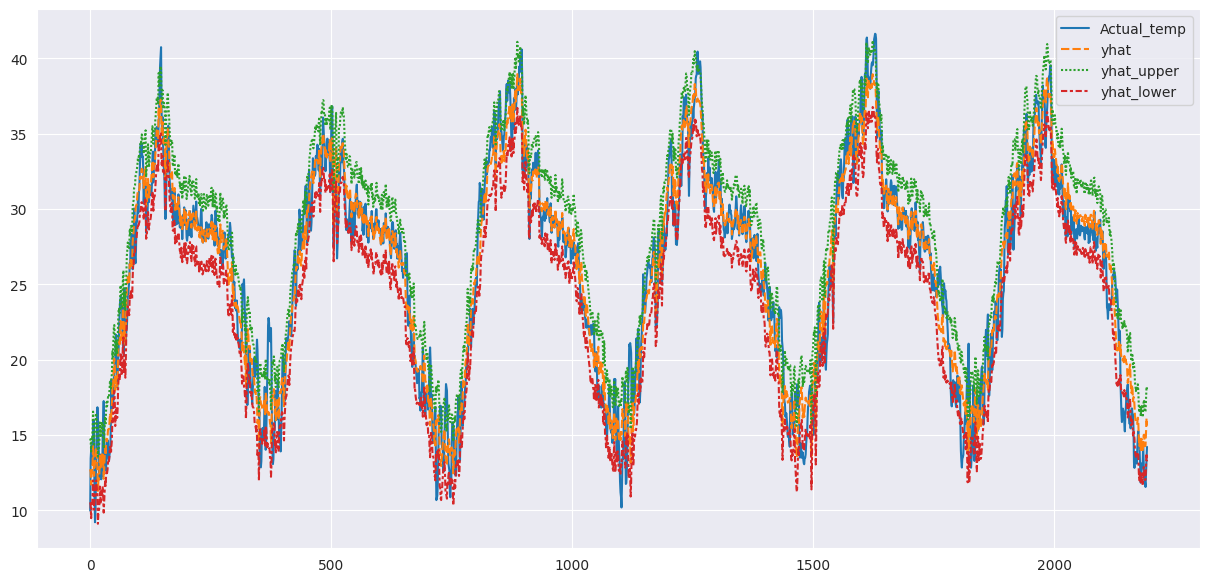

In [64]:
sns.lineplot(data = forecast[['Actual_temp', 'yhat',
             'yhat_upper', 'yhat_lower']])

There isn't a big gap between yhat_lower and yhat_upper, so we can trust this model

# 9. ARIMA, SARIMA and Prophet Models Comparision

In [65]:
display(test.head(2)) # test data from arima sarima models

display(p_test.head(2)) # test data from prophet model

,meantemp,humidity,wind_speed,meantemp_diff
date,,,,
2024-10-20,24.80,74.72,1.91,-0.35
2024-10-21,24.17,76.51,2.00,-0.63


,ds,y,humidity,wind_speed
1754,2024-10-20,24.80,74.72,1.91
1755,2024-10-21,24.17,76.51,2.00


In [66]:
pred_df = test.copy()  # copying test data from arima sarima models (for daily comparision)
pred_df.head()

,meantemp,humidity,wind_speed,meantemp_diff
date,,,,
2024-10-20,24.80,74.72,1.91,-0.35
2024-10-21,24.17,76.51,2.00,-0.63
2024-10-22,24.28,79.63,2.43,0.11
2024-10-23,24.91,82.16,2.42,0.63
2024-10-24,25.67,84.50,2.63,0.76


In [67]:
display(m_test.head()) # monthly test data

m_test["arima_mon_pred"] = arima_mon_pred.values.round(2)
m_test["sarima_mon_pred"] = sarima_mon_pred.values.round(2)

display(m_test.head())

,meantemp,humidity,wind_speed,meantemp_diff
date,,,,
2024-11-30,21.067333,67.108000,2.330333,-0.261000
2024-12-31,16.595806,59.023548,2.586774,-0.086452
2025-01-31,16.549355,48.603548,2.719677,0.217742
2025-02-28,21.543571,30.038929,3.158214,0.161071
2025-03-31,27.466774,20.492581,3.520645,0.087419


,meantemp,humidity,wind_speed,meantemp_diff,arima_mon_pred,sarima_mon_pred
date,,,,,,
2024-11-30,21.067333,67.108000,2.330333,-0.261000,24.00,20.84
2024-12-31,16.595806,59.023548,2.586774,-0.086452,23.24,17.14
2025-01-31,16.549355,48.603548,2.719677,0.217742,23.64,16.05
2025-02-28,21.543571,30.038929,3.158214,0.161071,24.83,21.46
2025-03-31,27.466774,20.492581,3.520645,0.087419,26.25,28.16


In [68]:
# Adding predictions of ARIMA, SARIMA and Prophet

pred_df["arima_daily_pred"] = arima_daily_pred.values.round(2)
pred_df["sarima_daily_pred"] = sarima_daily_pred.values.round(2)
pred_df["prophet_yhat"] = predicted.values.round(2)

pred_df.head()

,meantemp,humidity,wind_speed,meantemp_diff,arima_daily_pred,sarima_daily_pred,prophet_yhat
date,,,,,,,
2024-10-20,24.80,74.72,1.91,-0.35,25.11,25.42,25.16
2024-10-21,24.17,76.51,2.00,-0.63,25.07,25.38,24.74
2024-10-22,24.28,79.63,2.43,0.11,25.02,25.13,24.11
2024-10-23,24.91,82.16,2.42,0.63,24.98,24.92,23.48
2024-10-24,25.67,84.50,2.63,0.76,24.94,24.66,22.91


In [69]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import math

prophet_mape = mean_absolute_percentage_error(pred_df["meantemp"].values, pred_df["prophet_yhat"].values)
prophet_r = r2_score(pred_df["meantemp"].values, pred_df["prophet_yhat"].values)
prophet_rmse = math.sqrt(mean_squared_error(pred_df["meantemp"].values, pred_df["prophet_yhat"].values))

arima_mape = mean_absolute_percentage_error(pred_df["meantemp"].values, pred_df["arima_daily_pred"].values)
arima_r = r2_score(pred_df["meantemp"].values, pred_df["arima_daily_pred"].values)
arima_rmse = math.sqrt(mean_squared_error(pred_df["meantemp"].values, pred_df["arima_daily_pred"].values))

sarima_mape = mean_absolute_percentage_error(pred_df["meantemp"].values, pred_df["sarima_daily_pred"].values)
sarima_r = r2_score(pred_df["meantemp"].values, pred_df["sarima_daily_pred"].values)
sarima_rmse = math.sqrt(mean_squared_error(pred_df["meantemp"].values, pred_df["sarima_daily_pred"].values))

######## monthly predictions #############

arima_mape_m = mean_absolute_percentage_error(m_test["meantemp"].values, m_test["arima_mon_pred"].values)
arima_r_m = r2_score(m_test["meantemp"].values, m_test["arima_mon_pred"].values)
arima_rmse_m = math.sqrt(mean_squared_error(m_test["meantemp"].values, m_test["arima_mon_pred"].values))

sarima_mape_m = mean_absolute_percentage_error(m_test["meantemp"].values, m_test["sarima_mon_pred"].values)
sarima_r_m = r2_score(m_test["meantemp"].values, m_test["sarima_mon_pred"].values)
sarima_rmse_m = math.sqrt(mean_squared_error(m_test["meantemp"].values, m_test["sarima_mon_pred"].values))

compare_df = {
        'Prophet daily': [prophet_mape, prophet_rmse, prophet_r],
        'ARIMA daily': [arima_mape,arima_rmse,arima_r],
        'SARIMA daily': [sarima_mape,sarima_rmse,sarima_r],
        'ARIMA Monthly': [arima_mape_m,arima_rmse_m,arima_r_m],
        'SARIMA Monthly': [sarima_mape_m,sarima_rmse_m,sarima_r_m],
             }

compare_df = pd.DataFrame(compare_df,index=['MAE','RMSE','R2'])
compare_df

,Prophet daily,ARIMA daily,SARIMA daily,ARIMA Monthly,SARIMA Monthly
MAE,0.078642,0.287773,0.317332,0.278302,0.031348
RMSE,2.037580,7.129278,7.429023,6.409952,0.789394
R2,0.918313,-0.000032,-0.085891,0.211236,0.988037


# 10. Data Preprocessing before Deep Learning Models

In [70]:
df.head()

,meantemp,humidity,wind_speed
date,,,
2020-01-01,9.98,82.94,2.09
2020-01-02,13.44,84.70,2.25
2020-01-03,14.00,92.51,2.01
2020-01-04,14.31,85.76,1.95
2020-01-05,13.15,83.57,3.29


## 10.1 Train Test Split

In [71]:
# Split the data into training and testing sets
train_size = int(len(df) * 0.8)
dl_train = df.iloc[:train_size].copy()
dl_test = df.iloc[train_size:].copy()
print(len(dl_train), len(dl_test))

1754 439


## 10.2 Scaling

### Which models require scaling? <br>

#### 1. ARIMA and SARIMA: 
These models typically do not require scaling because they work with the raw time series data. However, if data has a wide range of values or when dealing with different scales across features, scaling might help improve model performance.

#### 2. Prophet: 
Prophet does not require scaling. It is robust to outliers and can handle non-stationary data directly.

#### 3. RNN, LSTM, and GRU: 
These models often benefit from scaling, especially while using activation functions like sigmoid or tanh, which are sensitive to the scale of the input data. Scaling helps stabilize training by putting all features on a similar scale, which can speed up convergence and prevent exploding gradients.

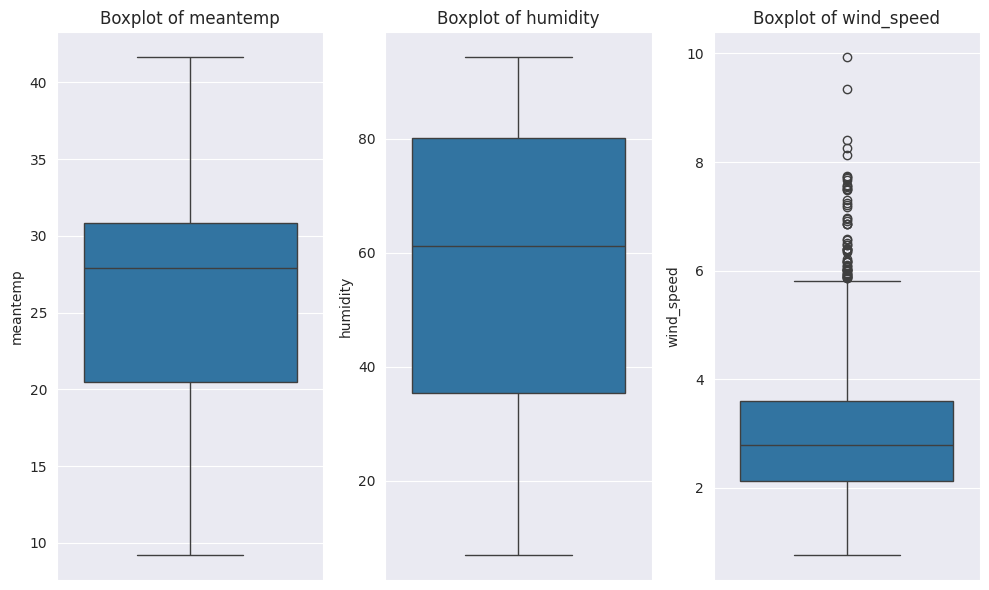

In [72]:
# find out what scaling to perform

f_columns = ['meantemp', 'humidity', 'wind_speed']
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1) 
sns.boxplot(y=df['meantemp'])
plt.title('Boxplot of meantemp')

plt.subplot(1, 3, 2) 
sns.boxplot(y=df['humidity'])
plt.title('Boxplot of humidity')

plt.subplot(1, 3, 3) 
sns.boxplot(y=df['wind_speed'])
plt.title('Boxplot of wind_speed')

plt.tight_layout() 
plt.show()

Applying: 

- MinMax scaling for meantemp and humidity
    - scaling the target meantemp separately


- Robust scaling for wind_speed

In [73]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

robust_scaler = RobustScaler()   # scaler for wind_speed
minmax_scaler = MinMaxScaler()  # scaler for humidity
target_transformer = MinMaxScaler()   # scaler for target (meantemp)

In [74]:
dl_train['wind_speed'] = robust_scaler.fit_transform(dl_train[['wind_speed']])  # robust for wind_speed
dl_train['humidity'] = minmax_scaler.fit_transform(dl_train[['humidity']]) # minmax for humidity
dl_train['meantemp'] = target_transformer.fit_transform(dl_train[['meantemp']]) # target

dl_test['wind_speed'] = robust_scaler.transform(dl_test[['wind_speed']])
dl_test['humidity'] = minmax_scaler.transform(dl_test[['humidity']])
dl_test['meantemp'] = target_transformer.transform(dl_test[['meantemp']])

In [75]:
display(df.head())
display(dl_train.head())

,meantemp,humidity,wind_speed
date,,,
2020-01-01,9.98,82.94,2.09
2020-01-02,13.44,84.70,2.25
2020-01-03,14.00,92.51,2.01
2020-01-04,14.31,85.76,1.95
2020-01-05,13.15,83.57,3.29


,meantemp,humidity,wind_speed
date,,,
2020-01-01,0.023751,0.875101,-0.456026
2020-01-02,0.130475,0.895361,-0.351792
2020-01-03,0.147748,0.985265,-0.508143
2020-01-04,0.157310,0.907563,-0.547231
2020-01-05,0.121530,0.882353,0.325733


# 11. Simple RNN

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

def create_dataset(X, y, time_steps=1):  
    Xs, ys = [], []   
    for i in range(len(X) - time_steps):   
        v = X.iloc[i:(i + time_steps)].values 
        Xs.append(v)      
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)  

2026-06-16 18:00:15.375233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781632815.394317   15546 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781632815.400465   15546 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781632815.416187   15546 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781632815.416202   15546 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781632815.416204   15546 computation_placer.cc:177] computation placer alr

This function prepares the input features and target values in the format required for training a recurrent neural network (RNN) or LSTM model for sequential prediction tasks. It creates sequences of input features and their corresponding target values, which can be fed into the model during training.

- X: This parameter represents the input features, typically a pandas DataFrame containing multiple time-series variables such as temperature, humidity, etc.
- y: This parameter represents the target values, which are typically the values we want to predict based on the input features.
- time_steps: This parameter defines the length of each sequence. It determines how many data points from the past will be used to predict the next data point. For example, if time_steps is set to 3, the function will create sequences of three consecutive data points as input features and the next data point as the target value.

In [77]:
# Create sequences
sequence_length = 3  # Example sequence length (adjust based on data and experimentation)
X_train, y_train = create_dataset(dl_train, dl_train['meantemp'], sequence_length)
X_test, y_test = create_dataset(dl_test, dl_test['meantemp'], sequence_length)

## 11.1 Model Training

In [78]:
# Build the model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(100, activation='tanh', input_shape=(sequence_length, X_train.shape[2])))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model with early stopping
history = rnn_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=1, callbacks=[early_stopping])

# Evaluate the model
loss = rnn_model.evaluate(X_test, y_test)
print(f'Validation Loss: {loss}')

I0000 00:00:1781632822.183925   15546 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781632822.189361   15546 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


I0000 00:00:1781632824.050891   15641 service.cc:152] XLA service 0x7ed7f000d020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781632824.050925   15641 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781632824.050929   15641 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781632824.199873   15641 cuda_dnn.cc:529] Loaded cuDNN version 91002


  70/1751 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1843

I0000 00:00:1781632824.637566   15641 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0233 - val_loss: 0.0030
Epoch 2/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 3/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0036 - val_loss: 0.0021
Epoch 4/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 5/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 6/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 7/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 8/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 9/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 10/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 12/30
1751/1751 ━━━━━━━━━━━━━━━━━━━

In [79]:
# Make predictions
rnn_pred = rnn_model.predict(X_test)
rnn_pred = target_transformer.inverse_transform(rnn_pred)  # Inverse transform to original scale

# Inverse transform the true values for comparison
y_test = y_test.reshape(-1, 1)
y_test = target_transformer.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [80]:
# Calculate RMSE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, rnn_pred))
r2 = r2_score(y_test, rnn_pred)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

RMSE: 1.033182105509508
R2 Score: 0.9791396992524979


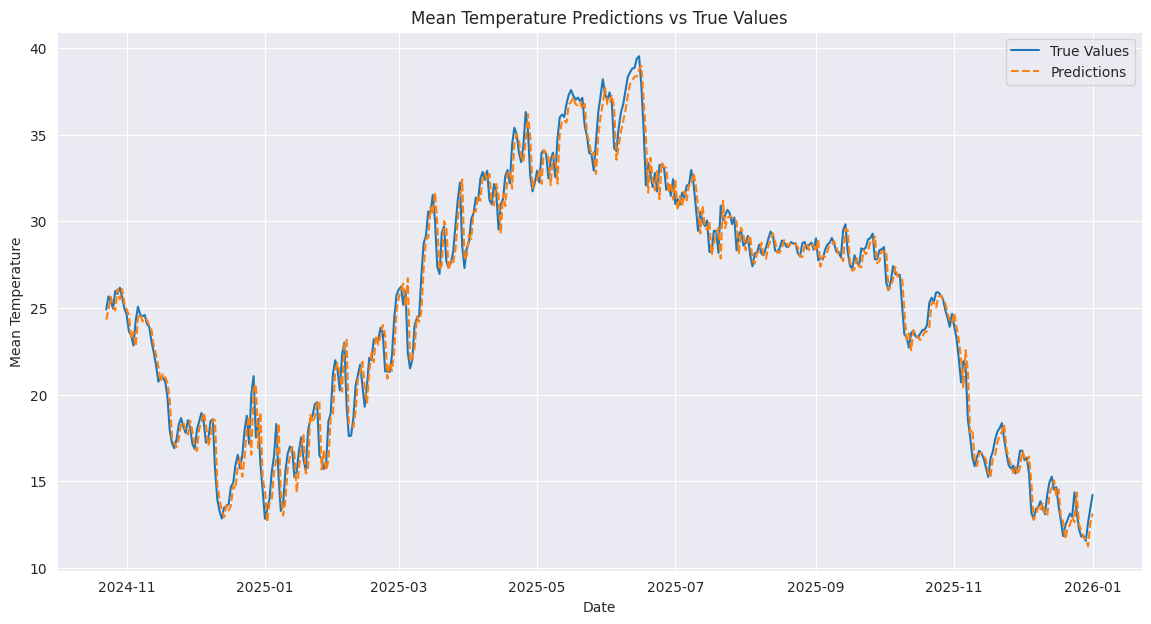

In [81]:
# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(y_test):], y_test, label='True Values')
plt.plot(df.index[-len(y_test):], rnn_pred, label='Predictions', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Mean Temperature Predictions vs True Values')
plt.legend()
plt.show()

In [82]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,505 (123.07 KB)

 Trainable params: 10,501 (41.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,004 (82.05 KB)

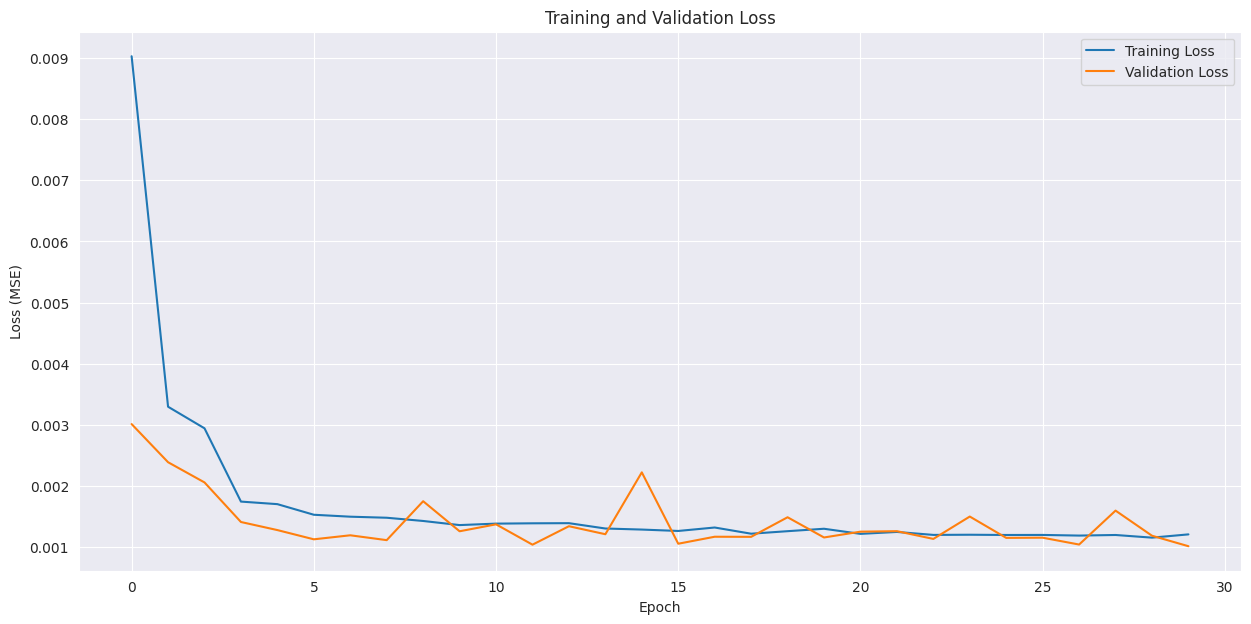

In [83]:
# Get training and validation losses from history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot loss values over epochs
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 11.2 Hyperparameter Tuning of RNN Model

In [84]:
import pandas as pd
import numpy as np
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define your search space based on your previous tests
activations = ['tanh', 'relu']
seq_lengths = [3, 7, 30]
neurons_list = [50, 100]
patiences = [5, 10]

# Create a list of all possible combinations
all_combinations = list(itertools.product(activations, seq_lengths, neurons_list, patiences))
print(f"Total models to train: {len(all_combinations)}")

# List to store the results
tuning_results = []

# 2. Loop through every combination
for activation, seq_len, neurons, patience in all_combinations:
    print(f"\n--- Training: Act={activation}, Seq={seq_len}, Neurons={neurons}, Patience={patience} ---")
    
    # STEP A: REBUILD DATA
    X_train, y_train = create_dataset(dl_train, dl_train['meantemp'], seq_len)
    X_test, y_test = create_dataset(dl_test, dl_test['meantemp'], seq_len)
    
    
    # STEP B: BUILD THE MODEL
    model = Sequential()
    # Assuming your data has 1 feature (like temperature), so shape is (seq_len, 1)
    model.add(SimpleRNN(neurons, activation=activation, input_shape=(seq_len, X_train.shape[2])))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')
    
    # STEP C: SET EARLY STOPPING
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=patience, 
        restore_best_weights=True
    )
    
    # STEP D: TRAIN
    # Using verbose=0 so output doesn't get flooded with progress bars
    model.fit(
        X_train, y_train, 
        epochs=50, # Set a high max epoch since Early Stopping will halt it anyway
        validation_data=(X_test, y_test), 
        batch_size=1, 
        callbacks=[early_stopping],
        verbose=0 
    )
    
    # STEP E: EVALUATE
    predictions = model.predict(X_test, verbose=0)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # STEP F: STORE RESULTS
    tuning_results.append({
        "Activation": activation,
        "Seq_Length": seq_len,
        "Neurons": neurons,
        "Patience": patience,
        "RMSE": rmse,
        "R2_Score": r2
    })

# 3. Analyze the Results
# Convert to DataFrame
df_results = pd.DataFrame(tuning_results)

# Sort by R2 Score to get the best models at the top
df_results = df_results.sort_values(by="R2_Score", ascending=False).reset_index(drop=True)

# Print the best result
print("\n=== BEST MODEL ===")
print(df_results.iloc[0])

# Display full leaderboard
display(df_results)

Total models to train: 24

--- Training: Act=tanh, Seq=3, Neurons=50, Patience=5 ---

--- Training: Act=tanh, Seq=3, Neurons=50, Patience=10 ---

--- Training: Act=tanh, Seq=3, Neurons=100, Patience=5 ---

--- Training: Act=tanh, Seq=3, Neurons=100, Patience=10 ---

--- Training: Act=tanh, Seq=7, Neurons=50, Patience=5 ---

--- Training: Act=tanh, Seq=7, Neurons=50, Patience=10 ---

--- Training: Act=tanh, Seq=7, Neurons=100, Patience=5 ---

--- Training: Act=tanh, Seq=7, Neurons=100, Patience=10 ---

--- Training: Act=tanh, Seq=30, Neurons=50, Patience=5 ---

--- Training: Act=tanh, Seq=30, Neurons=50, Patience=10 ---

--- Training: Act=tanh, Seq=30, Neurons=100, Patience=5 ---

--- Training: Act=tanh, Seq=30, Neurons=100, Patience=10 ---

--- Training: Act=relu, Seq=3, Neurons=50, Patience=5 ---

--- Training: Act=relu, Seq=3, Neurons=50, Patience=10 ---

--- Training: Act=relu, Seq=3, Neurons=100, Patience=5 ---

--- Training: Act=relu, Seq=3, Neurons=100, Patience=10 ---

--- Train

,Activation,Seq_Length,Neurons,Patience,RMSE,R2_Score
0,relu,3,50,5,0.030719,0.980618
1,relu,30,100,10,0.031771,0.980459
2,relu,30,50,5,0.031884,0.980319
3,relu,3,100,10,0.031102,0.980132
4,relu,7,50,10,0.031272,0.980097
5,relu,7,100,10,0.031281,0.980085
6,relu,3,50,10,0.031198,0.980008
7,tanh,7,100,10,0.031607,0.979669
8,tanh,30,50,10,0.032493,0.979560
9,relu,3,100,5,0.031566,0.979534


# 12. LSTM

## 12.1 Creating Dataset Sequences

In [85]:
sequence_length = 3  # Example sequence length (adjust based on your data and experimentation)
X_train, y_train = create_dataset(dl_train, dl_train['meantemp'], sequence_length)
X_test, y_test = create_dataset(dl_test, dl_test['meantemp'], sequence_length)

## 12.2 Model Training

In [86]:
from tensorflow.keras.layers import LSTM

# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(100, activation='tanh', input_shape=(sequence_length, X_train.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = lstm_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=1, callbacks=[early_stopping])

# Evaluate the model
loss = lstm_model.evaluate(X_test, y_test)
print(f'Validation Loss: {loss}')

Epoch 1/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0219 - val_loss: 0.0021
Epoch 2/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 3/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 4/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 5/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 6/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 8/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 9/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 10/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 12/30
1751/1751 ━━━━━━━━

In [87]:
lstm_model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,105 (488.70 KB)

 Trainable params: 41,701 (162.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 83,404 (325.80 KB)

In [88]:
# Make predictions
lstm_pred = lstm_model.predict(X_test)
lstm_pred = target_transformer.inverse_transform(lstm_pred)  # Inverse transform to original scale

# Inverse transform the true values for comparison
y_test = y_test.reshape(-1, 1)
y_test = target_transformer.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


RMSE: 1.009389624339418
R2 Score: 0.9800893936262677


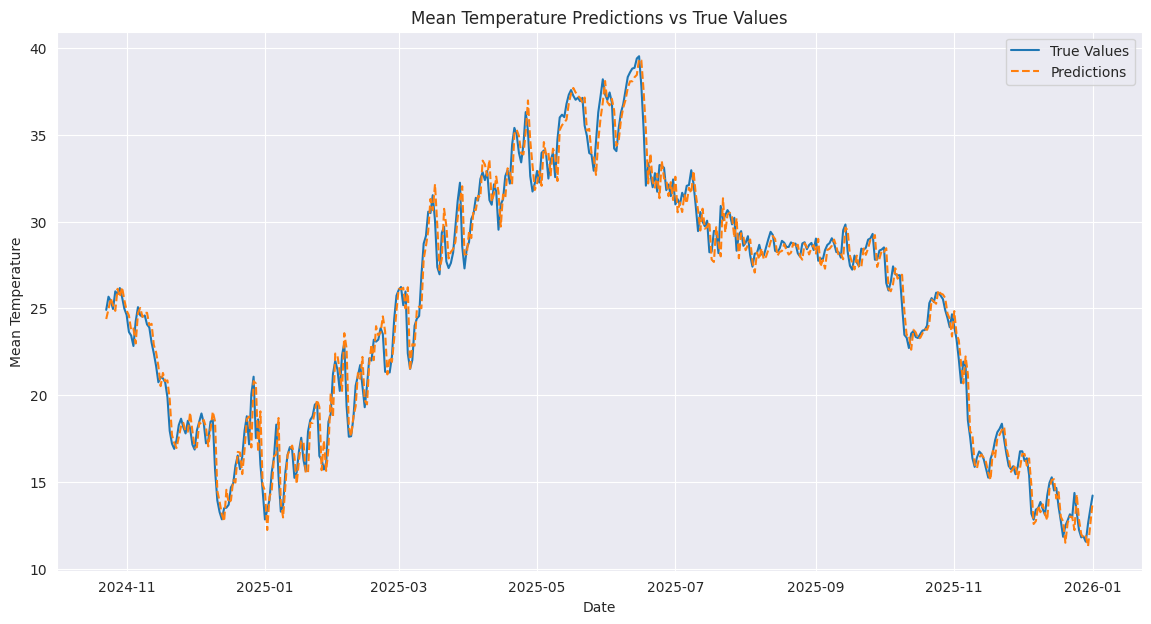

In [89]:
# Calculate RMSE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
r2 = r2_score(y_test, lstm_pred)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(y_test):], y_test, label='True Values')
plt.plot(df.index[-len(y_test):], lstm_pred, label='Predictions', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Mean Temperature Predictions vs True Values')
plt.legend()
plt.show()

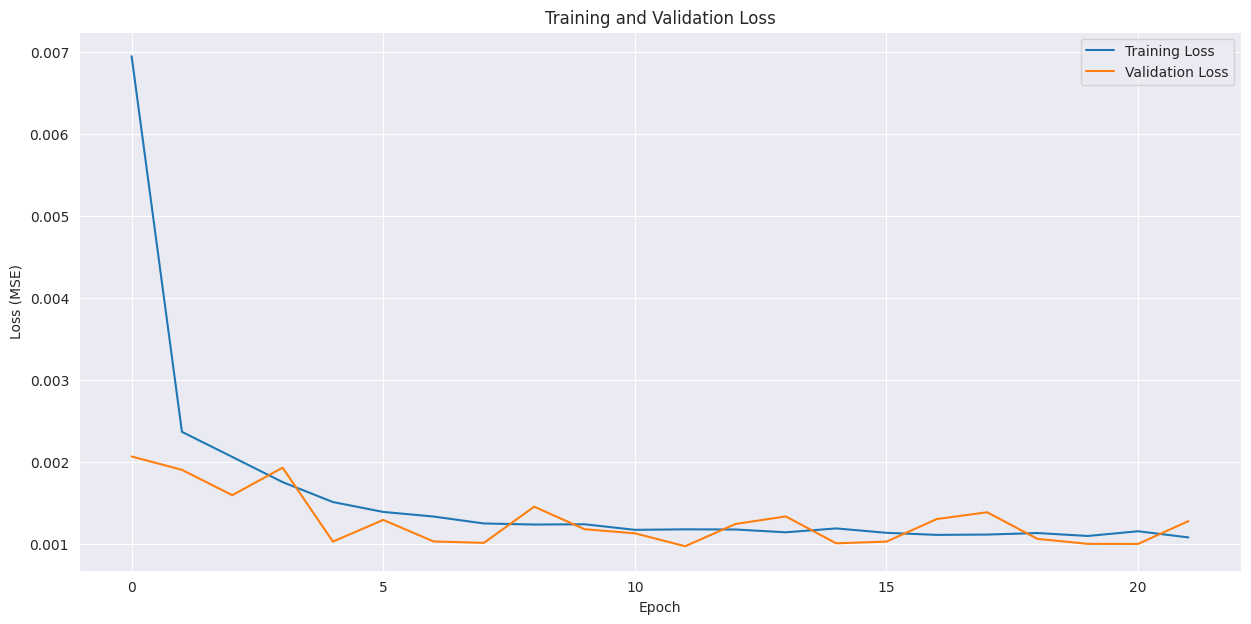

In [90]:
# Get training and validation losses from history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot loss values over epochs
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 12.3 Bidirectional LSTM
Bidirectional LSTMs are an extension of traditional LSTMs that can improve model performance on sequence classification problems.

In problems where all timesteps of the input sequence are available, Bidirectional LSTMs train two instead of one LSTMs on the input sequence. The first on the input sequence as-is and the second on a reversed copy of the input sequence. This can provide additional context to the network and result in faster and even fuller learning on the problem.

In [91]:
# Create sequences
sequence_length = 3  # Example sequence length (adjust based on your data and experimentation)
X_train, y_train = create_dataset(dl_train, dl_train['meantemp'], sequence_length)
X_test, y_test = create_dataset(dl_test, dl_test['meantemp'], sequence_length)

In [92]:
from tensorflow.keras.layers import LSTM, Bidirectional

# Build the bidirectional LSTM model
model = Sequential()
model.add(Bidirectional(LSTM(100, activation='tanh', input_shape=(sequence_length, X_train.shape[2]))))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=1, callbacks=[early_stopping])

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Validation Loss: {loss}')

Epoch 1/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0119 - val_loss: 0.0017
Epoch 2/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 3/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 4/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 5/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 6/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 7/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 8/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 9/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 12/30
1751/1751 ━━

In [93]:
model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (1, 200)               │        83,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (1, 1)                 │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,205 (977.37 KB)

 Trainable params: 83,401 (325.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 166,804 (651.58 KB)

In [94]:
# Make predictions
bilstm_pred = model.predict(X_test)
bilstm_pred = target_transformer.inverse_transform(bilstm_pred)  # Inverse transform to original scale

# Inverse transform the true values for comparison
y_test = y_test.reshape(-1, 1)
y_test = target_transformer.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


RMSE: 1.0499476694379812
R2 Score: 0.9784572013726768


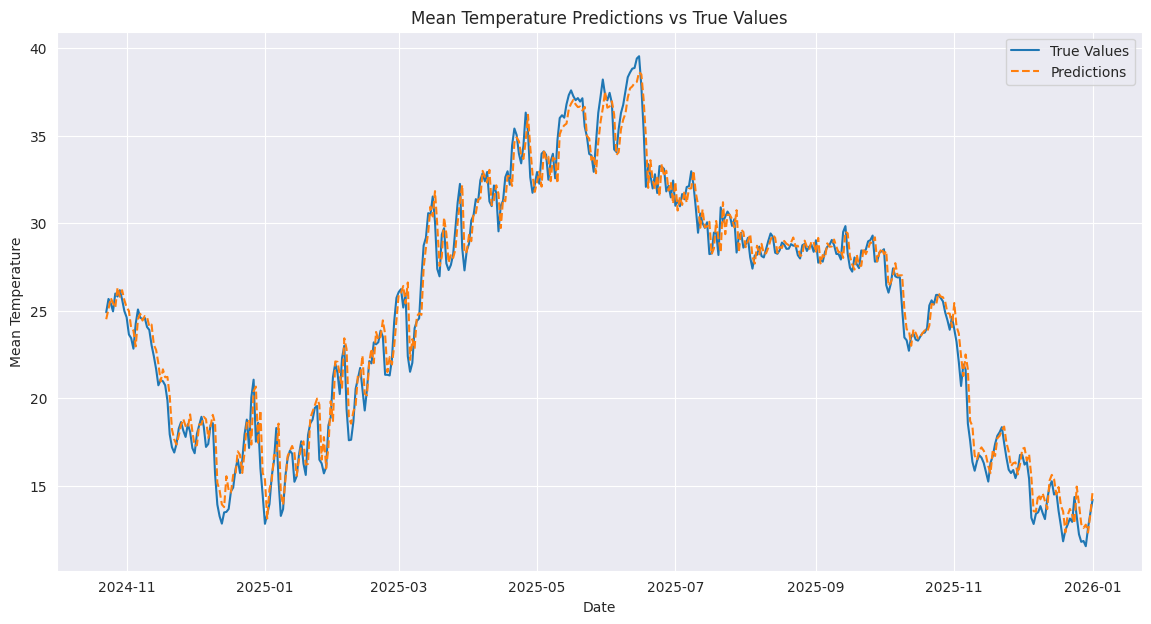

In [95]:
# Calculate RMSE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, bilstm_pred))
r2 = r2_score(y_test, bilstm_pred)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(y_test):], y_test, label='True Values')
plt.plot(df.index[-len(y_test):], bilstm_pred, label='Predictions', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Mean Temperature Predictions vs True Values')
plt.legend()
plt.show()

# 13 GRU Model

## 13.1 Create Dataset Sequences

In [96]:
# Create sequences
sequence_length = 3  # Example sequence length (adjust based on your data and experimentation)
X_train, y_train = create_dataset(dl_train, dl_train['meantemp'], sequence_length)
X_test, y_test = create_dataset(dl_test, dl_test['meantemp'], sequence_length)

## 13.2 Model Training

In [97]:
from tensorflow.keras.layers import GRU

# Build the GRU model
gru_model = Sequential()
gru_model.add(GRU(100, activation='tanh', input_shape=(sequence_length, X_train.shape[2])))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = gru_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=1, callbacks=[early_stopping])

# Evaluate the model
loss = gru_model.evaluate(X_test, y_test)
print(f'Validation Loss: {loss}')

Epoch 1/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0130 - val_loss: 0.0020
Epoch 2/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 3/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 4/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 8/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 9/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0012 - val_loss: 9.8462e-04
Epoch 10/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 11/30
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 12/30
1751/1751 ━━━━

In [98]:
gru_model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100)            │        31,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,805 (370.34 KB)

 Trainable params: 31,601 (123.44 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,204 (246.89 KB)

In [99]:
# Make predictions
gru_pred = gru_model.predict(X_test)
gru_pred = target_transformer.inverse_transform(gru_pred)  # Inverse transform to original scale

# Inverse transform the true values for comparison
y_test = y_test.reshape(-1, 1)
y_test = target_transformer.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


RMSE: 0.9970993764509912
R2 Score: 0.9805713017416576


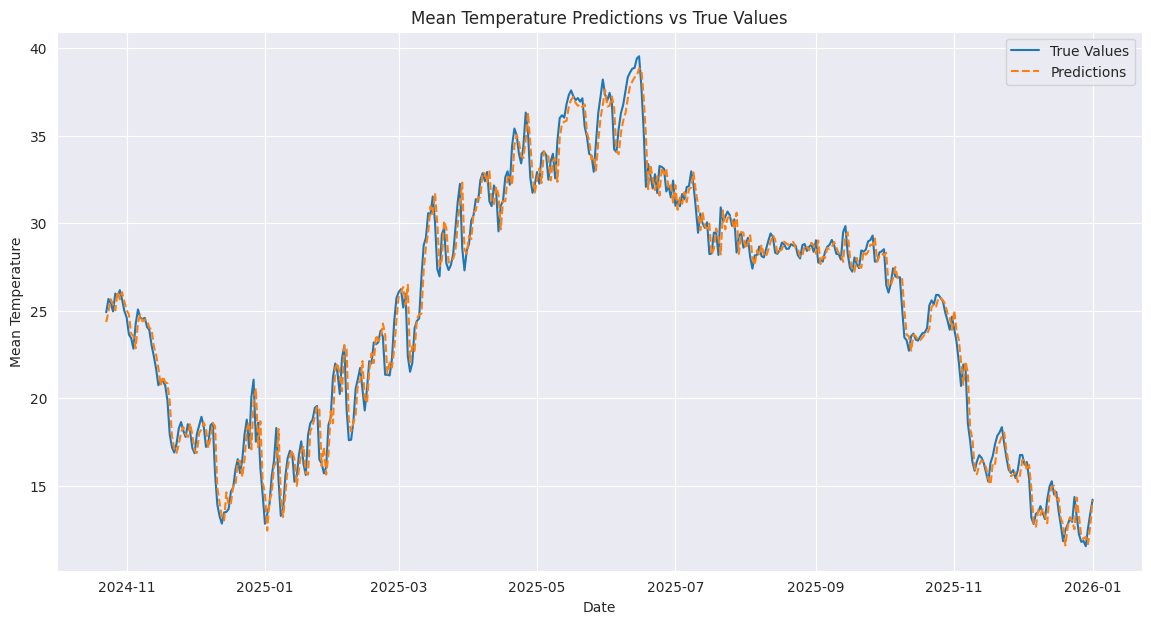

In [100]:
# Calculate RMSE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, gru_pred))
r2 = r2_score(y_test, gru_pred)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(y_test):], y_test, label='True Values')
plt.plot(df.index[-len(y_test):], gru_pred, label='Predictions', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Mean Temperature Predictions vs True Values')
plt.legend()
plt.show()

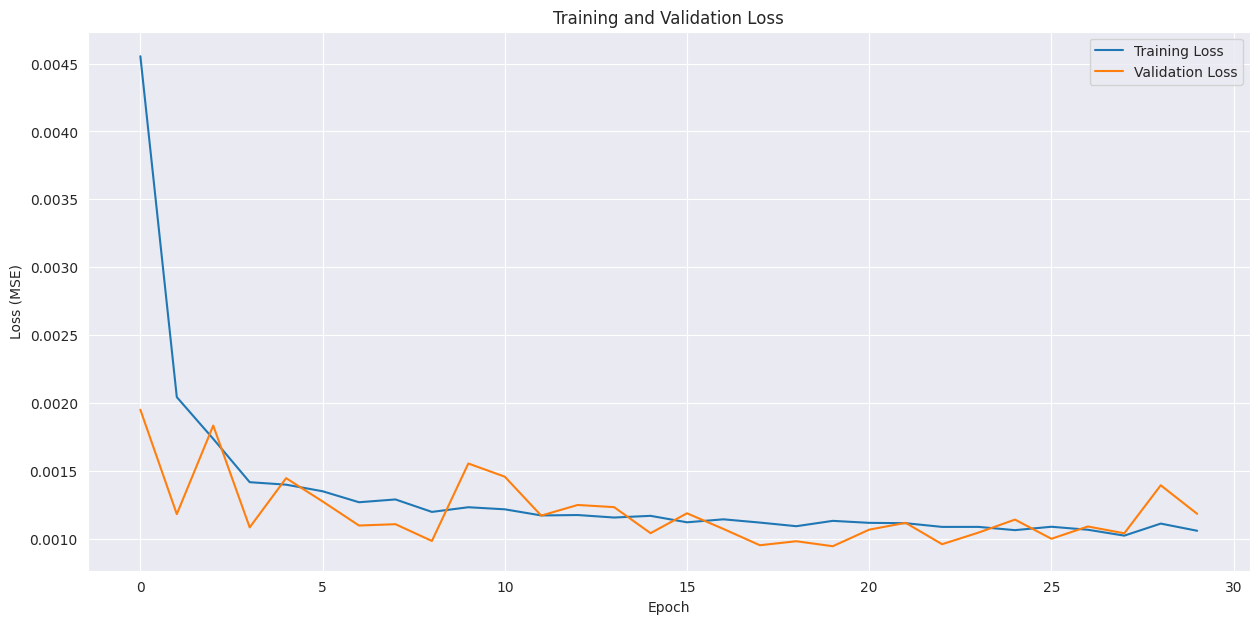

In [101]:
# Get training and validation losses from history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot loss values over epochs
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

All 3 Deep Learning model have approximately same performance
# 14. Model Comparision

In [102]:
display(pred_df.head())
display(compare_df.head())

,meantemp,humidity,wind_speed,meantemp_diff,arima_daily_pred,sarima_daily_pred,prophet_yhat
date,,,,,,,
2024-10-20,24.80,74.72,1.91,-0.35,25.11,25.42,25.16
2024-10-21,24.17,76.51,2.00,-0.63,25.07,25.38,24.74
2024-10-22,24.28,79.63,2.43,0.11,25.02,25.13,24.11
2024-10-23,24.91,82.16,2.42,0.63,24.98,24.92,23.48
2024-10-24,25.67,84.50,2.63,0.76,24.94,24.66,22.91


,Prophet daily,ARIMA daily,SARIMA daily,ARIMA Monthly,SARIMA Monthly
MAE,0.078642,0.287773,0.317332,0.278302,0.031348
RMSE,2.037580,7.129278,7.429023,6.409952,0.789394
R2,0.918313,-0.000032,-0.085891,0.211236,0.988037


In [103]:
rnn_mape = mean_absolute_percentage_error(y_test, rnn_pred)
rnn_r = r2_score(y_test, rnn_pred)
rnn_rmse = math.sqrt(mean_squared_error(y_test, rnn_pred))

lstm_mape = mean_absolute_percentage_error(y_test, lstm_pred)
lstm_r = r2_score(y_test, lstm_pred)
lstm_rmse = math.sqrt(mean_squared_error(y_test, lstm_pred))

bilstm_mape = mean_absolute_percentage_error(y_test, bilstm_pred)
bilstm_r = r2_score(y_test, bilstm_pred)
bilstm_rmse = math.sqrt(mean_squared_error(y_test, bilstm_pred))

gru_mape = mean_absolute_percentage_error(y_test, gru_pred)
gru_r = r2_score(y_test, gru_pred)
gru_rmse = math.sqrt(mean_squared_error(y_test, gru_pred))

dl_compare = {
        'RNN daily': [rnn_mape,rnn_rmse,rnn_r], 
        'LSTM daily': [lstm_mape,lstm_rmse,lstm_r],
        'BiLSTM daily': [bilstm_mape,bilstm_rmse,bilstm_r],
        'GRU daily': [gru_mape,gru_rmse,gru_r]
             }

dl_compare = pd.DataFrame(dl_compare,index=['MAE','RMSE','R2'])

# Concatenate dl_compare with compare_df
compare_models_df = pd.concat([compare_df, dl_compare], axis=1)
compare_models_df

,Prophet daily,ARIMA daily,SARIMA daily,ARIMA Monthly,SARIMA Monthly,RNN daily,LSTM daily,BiLSTM daily,GRU daily
MAE,0.078642,0.287773,0.317332,0.278302,0.031348,0.033772,0.032798,0.035987,0.032788
RMSE,2.037580,7.129278,7.429023,6.409952,0.789394,1.033182,1.009390,1.049948,0.997099
R2,0.918313,-0.000032,-0.085891,0.211236,0.988037,0.979140,0.980089,0.978457,0.980571


In [104]:
compare_models_df.columns

Index(['Prophet daily', 'ARIMA daily', 'SARIMA daily', 'ARIMA Monthly',
       'SARIMA Monthly', 'RNN daily', 'LSTM daily', 'BiLSTM daily',
       'GRU daily'],
      dtype='object')

In [105]:
compare_models_df_daily = compare_models_df.drop(columns=["ARIMA Monthly", "SARIMA Monthly"])

In [106]:
# Extract each row by its index label and convert to a list
mae_list = compare_models_df_daily.round(3).loc['MAE'].tolist()
rmse_list = compare_models_df_daily.round(3).loc['RMSE'].tolist()
r2_list = compare_models_df_daily.round(3).loc['R2'].tolist()

# Optional: Print to verify
print("MAE List:", mae_list)
print("RMSE List:", rmse_list)
print("R2 List:", r2_list)

MAE List: [0.079, 0.288, 0.317, 0.034, 0.033, 0.036, 0.033]
RMSE List: [2.038, 7.129, 7.429, 1.033, 1.009, 1.05, 0.997]
R2 List: [0.918, -0.0, -0.086, 0.979, 0.98, 0.978, 0.981]


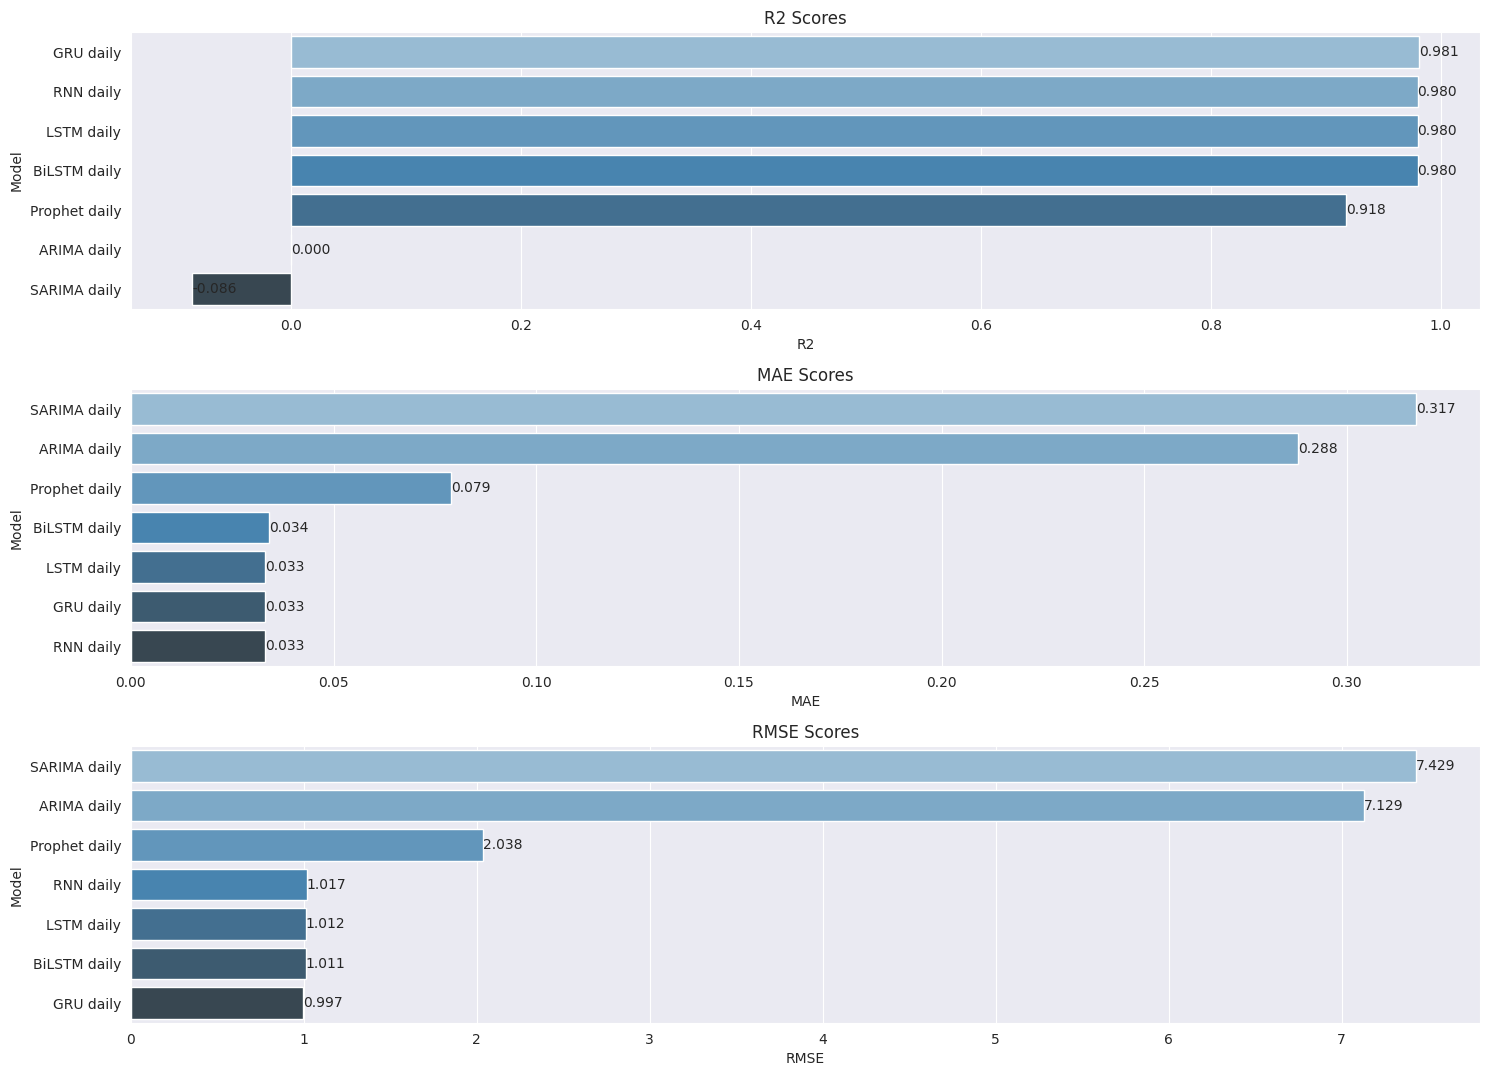

In [107]:
data = {
    'Model': ['Prophet daily', 'ARIMA daily', 'SARIMA daily', 'RNN daily', 'LSTM daily', 'BiLSTM daily', 'GRU daily'],
    'MAE': [0.079, 0.288, 0.317, 0.033, 0.033, 0.034, 0.033],
    'RMSE': [2.038, 7.129, 7.429, 1.017, 1.012, 1.011, 0.997],
    'R2': [0.918, -0.0, -0.086, 0.98, 0.98, 0.98, 0.981]
}

compare = pd.DataFrame(data)

def labels(ax):
    for p in ax.patches:
        width = p.get_width()                        
        ax.text(width,                              
                p.get_y() + p.get_height() / 2,     
                '{:.3f}'.format(width),             
                ha='left',                         
                va='center')  

plt.figure(figsize=(15, 14))

plt.subplot(411)
compare = compare.sort_values(by="R2", ascending=False)
ax = sns.barplot(x="R2", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('R2 Scores')

plt.subplot(412)
compare = compare.sort_values(by="MAE", ascending=False)
ax = sns.barplot(x="MAE", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('MAE Scores')

plt.subplot(413)
compare = compare.sort_values(by="RMSE", ascending=False)
ax = sns.barplot(x="RMSE", y="Model", data=compare, palette="Blues_d")
labels(ax)
plt.title('RMSE Scores')

plt.tight_layout()
plt.show()

# 15. Conclusion

After exploring various time series models in detail and leveraging advanced visualizations, it can be concluded that Prophet is the preferred choice among the other models. Despite testing over 6 models in a multivariate time series, Prophet's simplicity, performance, and cost-effectiveness make it the standout solution.

Prophet is able to deliver comparable results to deep learning models without the complexity and resource-intensive training they require. Unlike traditional ARIMA models, it offers a user-friendly interface and requires minimal parameter tuning, making it accessible to users with varying levels of expertise. Also, Prophet's robustness to outliers and its ability to handle irregularly spaced data add to its appeal.